In [1]:
# 1st: clean_spark
# 2nd: if doesn't work, clean_spark + restart kernel
# 3rd: if doesn't work, podman-compose down

In [2]:
# censys_pdf = censys_df.pandas_api()  # OK, SUBSET OF PANDAS API
# censys_df.toPandas()  # BE CAREFUL, THIS MAY CRASH YOUR ENVIRONMENT (needs podman-compose down)

In [3]:
# this creates your spark instance; if you clean_spark, you need to run this again
# you likely don't need to change the configurations inside this file
%run ../spark-instance.ipynb

SparkConf created
Started SparkSession
Spark version 3.5.3
You should be able to access the Spark UI at: https://dacs-compute-gate.ewi.utwente.nl:9999/user/remi.hendriks@utwente.nl/proxy/4040/stages/
Note that you may have to Enable extensions first via the Extension Manager.


In [4]:
# RUN THIS BEFORE RESTARTING THE PYTHON KERNEL
# RUN THIS IF YOU WANT TO RESTART YOUR SPARK INSTANCE
# run podman-compose down if you mess up this and you need to restart your jupyter
clean_spark()

In [5]:
# INSTALL ANY PYTHON PACKAGE YOU NEED HERE!!
# restart the kernel after installing new pkgs
#!pip install <pkg_name>

In [6]:
# system imports
import os
from datetime import datetime

# installed pkg imports
import numpy as np
import pandas as pd
import ipaddress

# spark imports
import pyspark.sql.functions as psf
import pyspark.sql.types as pst
from pyspark.storagelevel import StorageLevel
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, StringType, LongType, BooleanType, ArrayType, DoubleType



# download anycast census
import requests # query github
import gzip # read .json.gz files


# plotting
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import matplotlib.patheffects as path_effects

# configure matplotlib variables (font and size)
plt.rcParams["axes.labelsize"] = 20
plt.rcParams.update({'font.size': 14})


In [7]:
# About Censys data: https://search.censys.io/
# https://search.censys.io/search/definitions?resource=hosts

# you have access to the following dates:
#year=2023/month=08/day=22
#year=2023/month=09/day=19
#year=2023/month=10/day=24
#year=2023/month=11/day=21
#year=2023/month=12/day=19
#year=2024/month=01/day=16
#year=2024/month=02/day=20
#year=2024/month=03/day=12

#year=2024/month=09/day=10 is the latest matching

ts = datetime(2024, 9, 10)  # year=2024/month=01/day=16
CENSYS_BASE_PATH_FMT = "s3a://censys/dataset=universal-internet-dataset-v2-ipv4/format=parquet/"
CENSYS_PATH_FMT = os.path.join(CENSYS_BASE_PATH_FMT, "year={year}/month={month:02d}/day={day:02d}")

#IP2location dataset TODO upload
LOCATION_BASE_PATH = "../dataset/warehouse/"
LOCATION_FILE_NAME = "20240909_netstats_ip2location.csv"

In [8]:
censys_path = CENSYS_PATH_FMT.format(year=ts.year, month=ts.month, day=ts.day)
censys_df = spark.read.option("basePath", CENSYS_BASE_PATH_FMT).parquet(censys_path)

In [9]:
def download_date(year, month, day, version) -> pd.DataFrame:
    """Download and return census data for a specific date as a DataFrame.

    Args:
        year (int): The year of the data to download.
        month (int): The month of the data to download.
        day (int): The day of the data to download.
        version (str): The version of the census data ('v4' or 'v6').

    Returns:
        pd.DataFrame: DataFrame containing the census data for the specified date.
    """
    # Return error if date is before census start (2024/03/20)
    if (year, month, day) < (2024, 3, 20):
        raise ValueError("Date is before census start date of 2024-03-20")

    # Return error if date is in the future
    if datetime(year, month, day) > datetime.now():
        raise ValueError("Date is in the future")

    # URL e.g., https://github.com/ut-dacs/anycast-census/blob/main/2025/10/31/IPv4.parquet
    date_str = f"{year:04d}/{month:02d}/{day:02d}"
    url = f"https://github.com/ut-dacs/anycast-census/blob/main/{date_str}/IP{version}.parquet?raw=true"

    response = requests.get(url)
    if response.status_code != 200:
        raise Exception(f"Failed to download {url}: HTTP {response.status_code}")

    # Get the URL content as a bytes object
    data_bytes = response.content
    # Read the Parquet data into a DataFrame
    df = pd.read_parquet(pd.io.common.BytesIO(data_bytes))
    return df

In [10]:
# ip_location = os.path.join(LOCATION_BASE_PATH, LOCATION_FILE_NAME)
# ip_location_df = spark.read.option("header", True).csv(ip_location)
# #ip_location_df.show(5, truncate = False)

In [11]:
# censys schema TODO assess interesting fields from this
censys_df.printSchema()

root
 |-- host_identifier: struct (nullable = true)
 |    |-- ipv4: string (nullable = true)
 |    |-- ipv6: string (nullable = true)
 |    |-- name: string (nullable = true)
 |-- services: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- port: long (nullable = true)
 |    |    |-- transport: string (nullable = true)
 |    |    |-- service_name: string (nullable = true)
 |    |    |-- perspective: string (nullable = true)
 |    |    |-- observed_at: timestamp (nullable = true)
 |    |    |-- tls: struct (nullable = true)
 |    |    |    |-- version_selected: string (nullable = true)
 |    |    |    |-- cipher_selected: string (nullable = true)
 |    |    |    |-- certificates: struct (nullable = true)
 |    |    |    |    |-- leaf_fp_sha_256: binary (nullable = true)
 |    |    |    |    |-- chain_fps_sha_256: array (nullable = true)
 |    |    |    |    |    |-- element: binary (containsNull = true)
 |    |    |    |    |-- leaf_data: struct (null

In [12]:
# define LACeS struct

# locations of anycast sites
location_struct = StructType([
    StructField("city", StringType(), True),
    StructField("code_country", StringType(), True), 
    StructField("id", StringType(), True),
    StructField("latitude", DoubleType(), True), 
    StructField("longitude", DoubleType(), True)
])

# schema
full_schema = StructType([
    StructField("prefix", StringType(), True),
    StructField("AB_ICMPv4", LongType(), True),
    StructField("AB_TCPv4", LongType(), True),
    StructField("AB_DNSv4", LongType(), True),
    StructField("GCD_ICMPv4", LongType(), True),
    StructField("GCD_TCPv4", LongType(), True),
    StructField("partial", BooleanType(), True),
    StructField("backing_prefix", StringType(), True),
    StructField("ASN", StringType(), True),
    # list of location structs
    StructField("locations", ArrayType(location_struct), True) 
])


In [13]:
# load in anycast data

anycast_df = download_date(ts.year, ts.month, ts.day, "v4")
anycast_df = anycast_df[anycast_df['GCD_ICMPv4'] > 1] # filter on GCD-confirmed (high accuracy)

anycast_df.head()

,prefix,AB_ICMPv4,AB_TCPv4,AB_DNSv4,GCD_ICMPv4,GCD_TCPv4,partial,backing_prefix,ASN,locations
0,1.0.0.0/24,25,26,1,59,25,False,1.0.0.0/24,13335,"[{'city': 'Johannesburg', 'code_country': 'ZA'..."
1,1.1.1.0/24,25,25,26,59,21,False,1.1.1.0/24,13335,"[{'city': 'Bangalore', 'code_country': 'IN', '..."
2,1.10.10.0/24,2,0,2,3,0,False,1.10.10.0/24,148000,"[{'city': 'Mumbai', 'code_country': 'IN', 'id'..."
3,1.12.0.0/24,3,0,3,4,0,False,1.12.0.0/20,132203_45090,"[{'city': 'Frankfurt-am-Main', 'code_country':..."
4,1.12.12.0/24,3,1,0,4,1,False,1.12.0.0/20,132203_45090,"[{'city': 'Hong Kong', 'code_country': 'HK', '..."


In [14]:
anycast_spark_df = spark.createDataFrame(anycast_df, schema=full_schema)

anycast_spark_df.printSchema()
anycast_spark_df.show(1, truncate=False)

root
 |-- prefix: string (nullable = true)
 |-- AB_ICMPv4: long (nullable = true)
 |-- AB_TCPv4: long (nullable = true)
 |-- AB_DNSv4: long (nullable = true)
 |-- GCD_ICMPv4: long (nullable = true)
 |-- GCD_TCPv4: long (nullable = true)
 |-- partial: boolean (nullable = true)
 |-- backing_prefix: string (nullable = true)
 |-- ASN: string (nullable = true)
 |-- locations: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- city: string (nullable = true)
 |    |    |-- code_country: string (nullable = true)
 |    |    |-- id: string (nullable = true)
 |    |    |-- latitude: double (nullable = true)
 |    |    |-- longitude: double (nullable = true)

+----------+---------+--------+--------+----------+---------+-------+--------------+-----+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [15]:
# get unique anycast prefixes
anycast_prefixes = anycast_spark_df.select("prefix").distinct().collect()

# Show first 5 prefixes
print([row["prefix"] for row in anycast_prefixes[:5]])


['104.17.67.0/24', '104.18.188.0/24', '104.19.114.0/24', '104.17.232.0/24', '104.17.241.0/24']


In [16]:
# add /24 prefix column to censys data

censys_df = censys_df.withColumn(
    "prefix",
    psf.concat(
        psf.substring_index("host_identifier.ipv4", ".", 3), 
        psf.lit(".0/24")
    )
)

In [17]:
censys_selectives_df = censys_df.select(
    "prefix",
    "host_identifier",
    "services.port",
    "services.transport",
    "services.service_name",
    # "services.http.response.headers", -> originally used to infer number of unique websites (we use OI data for this)
    "autonomous_system", # contains more than just ASN
    #"locations", # spams output (put at end) -> temporarily disabled, explodes dataframe significantly (cause of slowness?)
)


anycast_selectives_df = anycast_spark_df.select(
    "prefix", 
    "GCD_ICMPv4", 
    "partial", 
    #"backing_prefix", 
    #"ASN"
)


# join censys and anycast datasets

# TODO handle MOASes (Verisign will show up with a lot of anycast ASes but in reality it's only a single AS)

censys_anycast_df = censys_selectives_df.join(
    F.broadcast(anycast_selectives_df),
    on="prefix",
    how="inner"
).select( # TODO add all required columns here
    "prefix",
    "GCD_ICMPv4",
    "partial",
    #"ASN", -> in 'autonomous_system'
    #"backing_prefix", -> in 'autonomous_system'
    "host_identifier",
    "port",
    "transport",
    "service_name",
    # "services.http.response.headers", -> originally used to infer number of unique websites (we use OI data for this)
    "autonomous_system", # contains more than just ASN
    #"locations", # spams output (put at end) -> temporarily disabled, explodes dataframe significantly (cause of slowness?)
)

In [18]:
# persist

censys_anycast_df.persist(StorageLevel.MEMORY_AND_DISK)
censys_anycast_df.count() # trigger persistance

# TODO save as file? so we can easily load in data next time?

2180518

In [19]:
# show first row
censys_anycast_df.show(1, truncate=False)

+---------------+----------+-------+--------------------------+-----------------------------+-------------------------+---------------------------------+-----------------------------------------------------------------+
|prefix         |GCD_ICMPv4|partial|host_identifier           |port                         |transport                |service_name                     |autonomous_system                                                |
+---------------+----------+-------+--------------------------+-----------------------------+-------------------------+---------------------------------+-----------------------------------------------------------------+
|43.159.102.0/24|14        |false  |{43.159.102.5, NULL, NULL}|[80, 443, 8080, 65530, 65531]|[TCP, TCP, TCP, TCP, TCP]|[HTTP, HTTP, HTTP, HTTP, UNKNOWN]|{139341, ACE-AS-AP ACE, 43.159.102.0/24, ACE-AS-AP ACE, SG, NULL}|
+---------------+----------+-------+--------------------------+-----------------------------+-------------------------+-

In [20]:
censys_anycast_df.printSchema()

root
 |-- prefix: string (nullable = true)
 |-- GCD_ICMPv4: long (nullable = true)
 |-- partial: boolean (nullable = true)
 |-- host_identifier: struct (nullable = true)
 |    |-- ipv4: string (nullable = true)
 |    |-- ipv6: string (nullable = true)
 |    |-- name: string (nullable = true)
 |-- port: array (nullable = true)
 |    |-- element: long (containsNull = true)
 |-- transport: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- service_name: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- autonomous_system: struct (nullable = true)
 |    |-- asn: long (nullable = true)
 |    |-- description: string (nullable = true)
 |    |-- bgp_prefix: string (nullable = true)
 |    |-- name: string (nullable = true)
 |    |-- country_code: string (nullable = true)
 |    |-- organization: string (nullable = true)



# General Data

In [84]:
total_anycast_ips = censys_anycast_df.select('host_identifier.ipv4').distinct().count()
total_anycast_prefixes = censys_anycast_df.select('prefix').distinct().count()
total_anycast_asns = censys_anycast_df.select('autonomous_system.asn').distinct().count()

# print(f"Original Censys IPs: {censys_df.select('host_identifier.ipv4').distinct().count():,}") 249,609,996
print(f"Total Censys IPs in Anycast subnets: {total_anycast_ips:,}")

Total Censys IPs in Anycast subnets: 2,180,518


In [22]:
unmatched_prefixes = anycast_selectives_df.select("prefix").distinct().join(
    censys_selectives_df.select("prefix").distinct(),
    on="prefix",
    how="left_anti"
)
total = anycast_selectives_df.select("prefix").distinct().count() # Total number of Anycast /24 prefixes
unmatched = unmatched_prefixes.count() # Anycast /24 prefixes that weren't found in the Censys data
matched = total - unmatched
print(f"Total anycast /24 prefixes: {total:,}")
print(f"Total unmatched prefixes: {unmatched:,}")
print(f"Total matched prefixes: {matched:,}")

print(f"Matched prefixes: {(100 * (total - unmatched) / total):.2f}%")
#print(f"Average IPs per /24 prefix: {(total_censys_anycast/matched):.2f}")

Total anycast /24 prefixes: 12,180
Total unmatched prefixes: 460
Total matched prefixes: 11,720
Matched prefixes: 96.22%


In [89]:
# get total number of services (exploded transport lists)
exploded_df = censys_anycast_df \
    .select(
        "host_identifier",
        "autonomous_system.asn",
        "prefix", 
        F.explode_outer("transport").alias("protocol")
    ) \
    .filter(F.col("protocol").isNotNull())

total_services_global = exploded_df.count() # total number of services found


# combine all metrics into one
# 1) total services for each transport layer protocol
# 2) total anycast IPs for each transport layer protocol (TODO should we exclude partial prefixes for this?)
# 3) total anycast prefixes for each transport layer protocol
protocol_stats = exploded_df \
    .groupBy("protocol") \
    .agg(
        # total services (e.g., IP has 3 TCP ports -> Count 3)
        F.count("*").alias("total_services"),
        
        # services by unique IPs (e.g., IP has 3 TCP ports -> Count 1) (e.g., how many IPs have a TCP service running?)
        F.countDistinct("host_identifier").alias("ip_count"),
        
        # services by unique prefixes (e.g., how many prefixes have a UDP service running
        F.countDistinct("prefix").alias("prefix_count"),

        # count by ASNs
        F.countDistinct("asn").alias("asn_count") 
    ) \
    .withColumn("services_pct", F.round((F.col("total_services") / total_services_global) * 100, 2)) \
    .withColumn("ip_pct", F.round((F.col("ip_count") / total_anycast_ips) * 100, 2)) \
    .withColumn("prefix_pct", F.round((F.col("prefix_count") / total_anycast_prefixes) * 100, 2)) \
    .withColumn("asn_pct", F.round((F.col("asn_count") / total_anycast_asns) * 100, 2)) \
    .select(
        "protocol", 
        "total_services", "services_pct", 
        "ip_count", "ip_pct", 
        "prefix_count", "prefix_pct",
        "asn_count", "asn_pct",
    ) \
    .orderBy(F.col("total_services").desc())

protocol_stats.show(truncate=False)

+--------+--------------+------------+--------+------+------------+----------+---------+-------+
|protocol|total_services|services_pct|ip_count|ip_pct|prefix_count|prefix_pct|asn_count|asn_pct|
+--------+--------------+------------+--------+------+------------+----------+---------+-------+
|TCP     |13775114      |97.95       |2111777 |96.85 |10356       |88.36     |508      |71.65  |
|QUIC    |147575        |1.05        |147575  |6.77  |4313        |36.8      |18       |2.54   |
|UDP     |140839        |1.0         |103816  |4.76  |5036        |42.97     |542      |76.45  |
+--------+--------------+------------+--------+------+------------+----------+---------+-------+



In [92]:
# convert to latex table

# convert to pandas first
pdf = protocol_stats.toPandas()

# format with thousand separator and percentage in paranthesis (e.g., `1,100,213 (81.23\%)`)
def format_metric(count, pct):
    return f"{int(count):,} ({pct:.0f}\\%)"

# combine counts and percentages
pdf['Total Services Combined'] = pdf.apply(
    lambda x: format_metric(x['total_services'], x['services_pct']), axis=1
)

pdf['IP Count Combined'] = pdf.apply(
    lambda x: format_metric(x['ip_count'], x['ip_pct']), axis=1
)

pdf['Prefix Count Combined'] = pdf.apply(
    lambda x: format_metric(x['prefix_count'], x['prefix_pct']), axis=1
)

pdf['ASN Count Combined'] = pdf.apply(
    lambda x: format_metric(x['asn_count'], x['asn_pct']), axis=1
)

# rename columns
final_table = pdf[[
    'protocol', 
    'Total Services Combined', 
    'IP Count Combined', 
    'Prefix Count Combined',
    'ASN Count Combined',
]]

final_table.columns = [
    "Protocol", 
    "Total Services", 
    "Active IPs", 
    "/24s",
    "ASes",
]

# generate latex
latex_output = final_table.to_latex(
    index=False,
    escape=False, 
    caption="Transport Layer Protocols Statistics",
    label="tab:transport_protocols"
)

print(latex_output)

\begin{table}
\caption{Transport Layer Protocols Statistics}
\label{tab:transport_protocols}
\begin{tabular}{lllll}
\toprule
Protocol & Total Services & Active IPs & /24s & ASes \\
\midrule
TCP & 13,775,114 (98\%) & 2,111,777 (97\%) & 10,356 (88\%) & 508 (72\%) \\
QUIC & 147,575 (1\%) & 147,575 (7\%) & 4,313 (37\%) & 18 (3\%) \\
UDP & 140,839 (1\%) & 103,816 (5\%) & 5,036 (43\%) & 542 (76\%) \\
\bottomrule
\end{tabular}
\end{table}



In [42]:
top_asns = censys_anycast_df \
    .groupBy(
        "autonomous_system.asn",
        "autonomous_system.name",
        #"autonomous_system.organization" always null
    ) \
    .agg(
        # IPs (each row has a unique IP)
        F.count("*").alias("IP count"),
        
        # anycast /24s
        F.countDistinct("prefix").alias("/24-prefix"),
        
        # bgp prefixes
        F.countDistinct("autonomous_system.bgp_prefix").alias("BGP-prefix"),
    ) \
    .withColumn("IP utilization", 
        F.round(
            (F.col("IP count") / (F.col("/24-prefix") * 256)) * 100, 
            2
        )
    ) \
    .orderBy(F.col("IP count").desc()) \
    .limit(20)

top_asns.show(truncate=False)

+------+-----------------------------------+--------+----------+----------+--------------+
|asn   |name                               |IP count|/24-prefix|BGP-prefix|IP utilization|
+------+-----------------------------------+--------+----------+----------+--------------+
|396982|GOOGLE-CLOUD-PLATFORM              |826588  |3351      |146       |96.36         |
|13335 |CLOUDFLARENET                      |746556  |3088      |348       |94.44         |
|54113 |FASTLY                             |115122  |454       |50        |99.05         |
|16509 |AMAZON-02                          |112578  |1042      |227       |42.2          |
|209242|CLOUDFLARESPECTRUM Cloudflare, Inc.|66527   |272       |226       |95.54         |
|15169 |GOOGLE                             |50877   |219       |19        |90.75         |
|15967 |NETARTGROUP                        |46904   |191       |41        |95.93         |
|15133 |EDGECAST                           |22785   |151       |151       |58.94         |

In [38]:
top_asns = censys_anycast_df \
    .groupBy(
        "autonomous_system.asn",
        "autonomous_system.name",
        #"autonomous_system.organization" always null
    ) \
    .agg(
        # IPs (each row has a unique IP)
        F.count("*").alias("IP count"),
        
        # anycast /24s
        F.countDistinct("prefix").alias("/24-prefix"),
        
        # bgp prefixes
        F.countDistinct("autonomous_system.bgp_prefix").alias("BGP-prefix"),
    ) \
    .withColumn("IP utilization", 
        F.round(
            (F.col("IP count") / (F.col("/24-prefix") * 256)) * 100, 
            2
        )
    ) \
    .orderBy(F.col("/24-prefix").desc()) \
    .limit(10)

top_asns.show(truncate=False)

+------+-----------------------------------+--------+----------+----------+--------------+
|asn   |name                               |IP count|/24-prefix|BGP-prefix|IP utilization|
+------+-----------------------------------+--------+----------+----------+--------------+
|396982|GOOGLE-CLOUD-PLATFORM              |826588  |3351      |146       |96.36         |
|13335 |CLOUDFLARENET                      |746556  |3088      |348       |94.44         |
|16509 |AMAZON-02                          |112578  |1042      |227       |42.2          |
|54113 |FASTLY                             |115122  |454       |50        |99.05         |
|209242|CLOUDFLARESPECTRUM Cloudflare, Inc.|66527   |272       |226       |95.54         |
|12041 |AS-AFILIAS1                        |2075    |224       |224       |3.62          |
|40509 |FLY                                |19949   |220       |115       |35.42         |
|15169 |GOOGLE                             |50877   |219       |19        |90.75         |

In [37]:
# convert to latex table

# only pandas has to latex
pandas_df = top_asns.toPandas()

# thousand separators and % signs
formatters = {
    "IP count": "{:,}".format,
    "/24-prefix": "{:,}".format, 
    "BGP-prefix": "{:,}".format,
    "IP utilization": "{:.2f}\\%".format 
}

# generate latex
latex_output = pandas_df.to_latex(
    index=False, 
    formatters=formatters,
    escape=False, 
    caption="Top 10 anycast ASNs by number of active anycast IPs and utilization",
    label="tab:top_ases"
)

print(latex_output)

\begin{table}
\caption{Top 10 anycast ASNs by number of active anycast IPs and utilization}
\label{tab:top_ases}
\begin{tabular}{rlrrrr}
\toprule
asn & name & IP count & /24-prefix & BGP-prefix & IP utilization \\
\midrule
396982 & GOOGLE-CLOUD-PLATFORM & 826,588 & 3,351 & 146 & 96.36\% \\
13335 & CLOUDFLARENET & 746,556 & 3,088 & 348 & 94.44\% \\
54113 & FASTLY & 115,122 & 454 & 50 & 99.05\% \\
16509 & AMAZON-02 & 112,578 & 1,042 & 227 & 42.20\% \\
209242 & CLOUDFLARESPECTRUM Cloudflare, Inc. & 66,527 & 272 & 226 & 95.54\% \\
15169 & GOOGLE & 50,877 & 219 & 19 & 90.75\% \\
15967 & NETARTGROUP & 46,904 & 191 & 41 & 95.93\% \\
15133 & EDGECAST & 22,785 & 151 & 151 & 58.94\% \\
40509 & FLY & 19,949 & 220 & 115 & 35.42\% \\
207266 & AFILIAS-SECONDARY-DNS & 19,308 & 77 & 77 & 97.95\% \\
\bottomrule
\end{tabular}
\end{table}



In [28]:
# calculate IP utilization per /24 prefix and per AS


# per prefix
# count IPs in the prefix / 256 -> IP utilization
prefix_util_df = censys_anycast_df \
    .groupBy("prefix") \
    .count() \
    .withColumn("utilization", F.round((F.col("count") / 256) * 100, 2)) \
    .select("utilization")

# per ASN
# total IPs in ASN / (total /24s in ASN * 256)
asn_util_df = censys_anycast_df \
    .groupBy("autonomous_system.asn") \
    .agg(
        F.count("*").alias("total_ips"),
        F.countDistinct("prefix").alias("total_prefixes")
    ) \
    .withColumn("utilization", 
        F.round(
            (F.col("total_ips") / (F.col("total_prefixes") * 256)) * 100, 
            2
        )
    ) \
    .select("utilization")

In [29]:
# convert to pandas for plotting
prefix_pdf = prefix_util_df.toPandas()
asn_pdf = asn_util_df.toPandas()

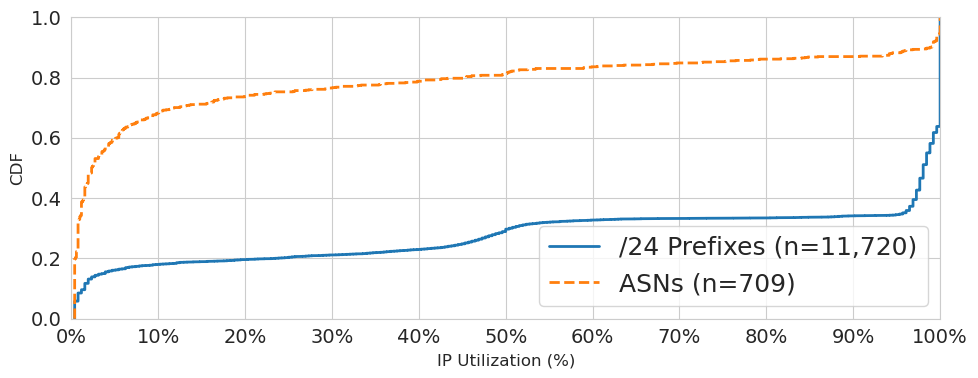

In [30]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 4))

# /24 prefix, IP utilization CDF
sns.ecdfplot(
    data=prefix_pdf, 
    x="utilization", 
    label=f"/24 Prefixes (n={len(prefix_pdf):,})",
    linewidth=2,
    color="#1f77b4" # blue
)

# ASN, IP utilization CDF

sns.ecdfplot(
    data=asn_pdf, 
    x="utilization", 
    label=f"ASNs (n={len(asn_pdf):,})", 
    linewidth=2, 
    linestyle="--",
    color="#ff7f0e" # orange
)

plt.xlabel("IP Utilization (%)", fontsize=12)
plt.ylabel("CDF", fontsize=12)

plt.xticks(np.arange(0, 101, 10))
plt.xlim(0, 100)

# add legend
plt.legend(fontsize=18)

# add percentage formatting to X axis
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()

# save fig
plt.savefig("utilization_cdf.pdf", format="pdf", bbox_inches='tight')

plt.show()

In [31]:
total_anycast_ases = censys_anycast_df.select('autonomous_system.asn').distinct().count()

print(f"Number of unique ASNs using Anycast: {total_anycast_ases:,}")
print(f"Number of unique BGP prefixes using Anycast: {censys_anycast_df.select('autonomous_system.bgp_prefix').distinct().count():,}")

Number of unique ASNs using Anycast: 709
Number of unique BGP prefixes using Anycast: 3,866


In [50]:
# plot distribution of IP count and prefixes count for ASes

asn_stats_df = censys_anycast_df \
    .groupBy("autonomous_system.asn") \
    .agg(
        F.count("*").alias("ip_count"),
        F.countDistinct("prefix").alias("prefix_count")
    )

stats_pdf = asn_stats_df.toPandas()

stats_pdf.describe()

,asn,ip_count,prefix_count
count,709.000000,709.000000,709.000000
mean,94938.362482,3075.483780,16.595205
std,113093.967998,42365.760252,177.090144
min,42.000000,1.000000,1.000000
25%,20940.000000,3.000000,1.000000
50%,44239.000000,11.000000,1.000000
75%,148000.000000,202.000000,3.000000
max,400797.000000,826588.000000,3351.000000


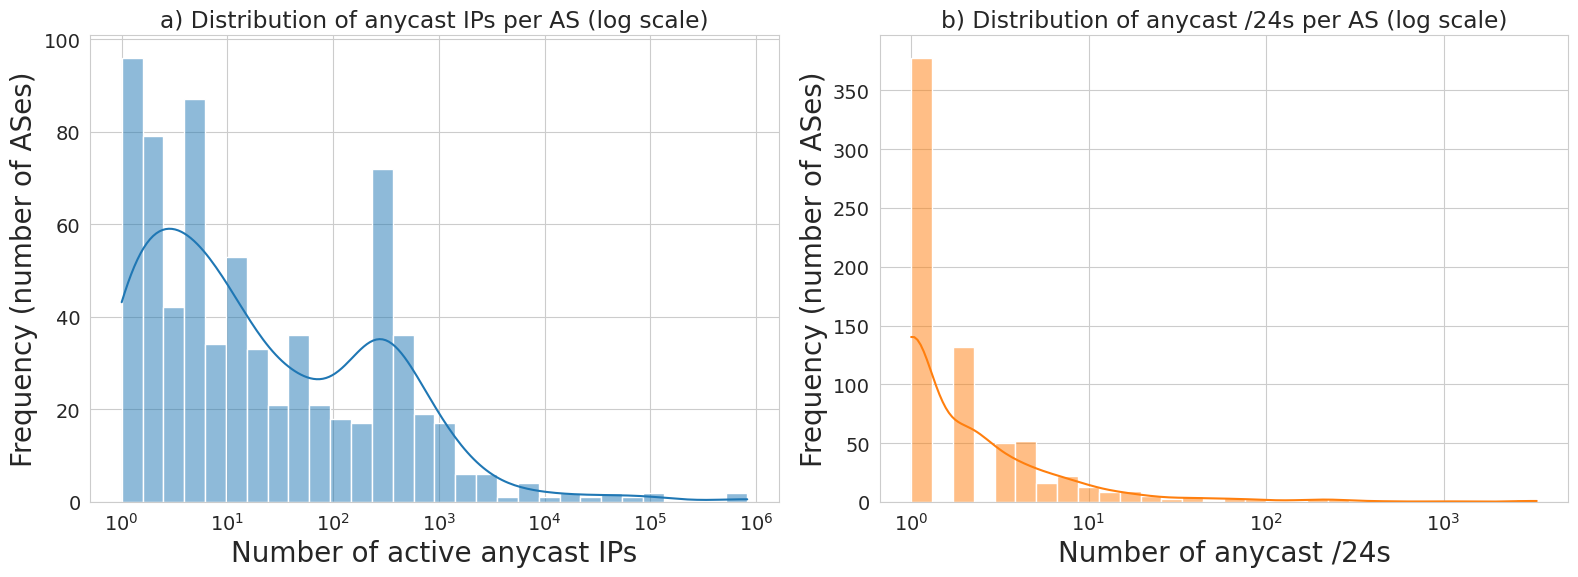

In [57]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# distribution of IPs per AS
sns.histplot(
    data=stats_pdf, 
    x="ip_count", 
    ax=axes[0], 
    log_scale=True,
    bins=30,
    kde=True,        # density line
    color="#1f77b4"
)
axes[0].set_title("a) Distribution of anycast IPs per AS (log scale)")
axes[0].set_xlabel("Number of active anycast IPs")
axes[0].set_ylabel("Frequency (number of ASes)")

# distribution of prefixes per AS
sns.histplot(
    data=stats_pdf, 
    x="prefix_count", 
    ax=axes[1], 
    log_scale=True, 
    bins=30,
    kde=True,        # density line
    color="#ff7f0e"
)
axes[1].set_title("b) Distribution of anycast /24s per AS (log scale)")
axes[1].set_xlabel("Number of anycast /24s")
axes[1].set_ylabel("Frequency (number of ASes)")

plt.savefig("output/distributions.pdf", bbox_inches='tight')

plt.tight_layout()
plt.show()

# Analyzing the services running on Anycast

In [32]:
service_freq = censys_anycast_df.select(
    psf.explode("service_name").alias("service"))
    .groupBy("service").count().orderBy("count", ascending=False)

service_freq.show(100,truncate=False)

+-------------------+--------+
|service            |count   |
+-------------------+--------+
|HTTP               |12893073|
|SMTP               |138929  |
|DNS                |90984   |
|IMAP               |88850   |
|POP3               |88301   |
|MYSQL              |62290   |
|FTP                |44718   |
|SVR                |34196   |
|POSTGRES           |31111   |
|SSH                |24950   |
|IKE                |4111    |
|SNMP               |1853    |
|NTP                |1754    |
|MINECRAFT          |1713    |
|HIKVISION          |1550    |
|TELNET             |1385    |
|MDNS               |1195    |
|EPMD               |1157    |
|SIP                |1116    |
|PORTMAP            |782     |
|CISCO_IPSLA        |762     |
|MURMUR             |729     |
|L2TP               |721     |
|KUBERNETES         |690     |
|COAP               |687     |
|MQTT               |618     |
|RDP                |480     |
|ZEROMQ             |374     |
|REDIS              |345     |
|CWMP   

In [33]:
print(f"Total distinct services (excluding UNKNOWN): {service_freq.count()}")

Total distinct services (excluding UNKNOWN): 96


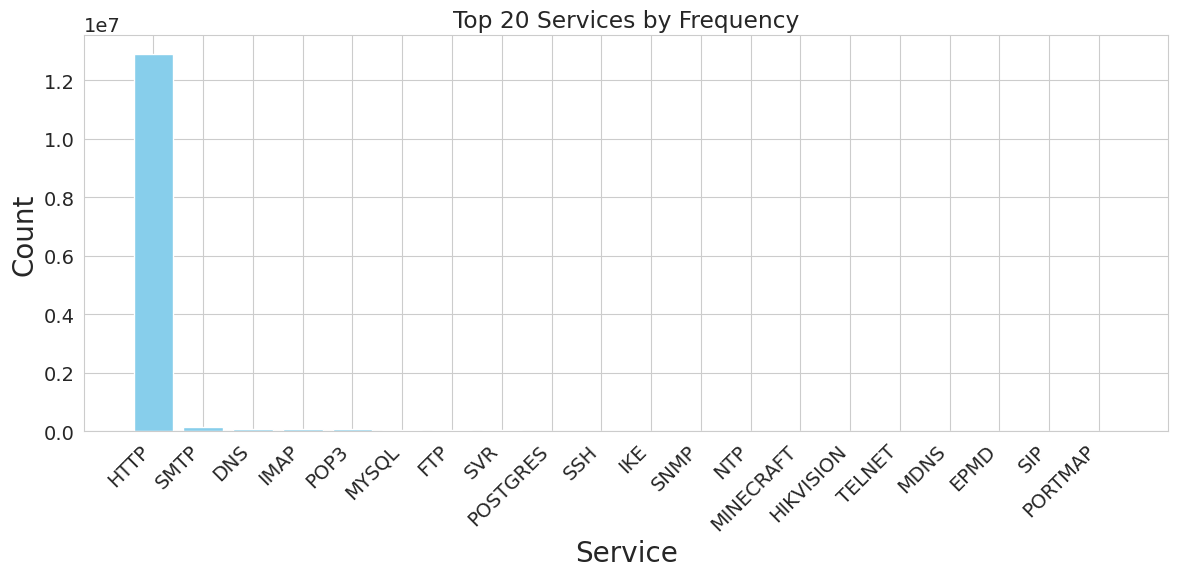

In [34]:
# Plotting a histogram by converting to pandas, top 20 services only
# This does not filter unique services per IP address
service_freq_pd = service_freq.limit(20).toPandas()
plt.figure(figsize=(12, 6))
plt.bar(service_freq_pd["service"], service_freq_pd["count"], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Service")
plt.ylabel("Count")
plt.title("Top 20 Services by Frequency")
plt.tight_layout()
plt.show()

### Above graph is highly skewed by CDNs deploying many http services per IP address

In [44]:

# We want unique services per IP, so for example multiple HTTP are counted as 1 
service_freq_unique = censys_anycast_df \
    .select("host_identifier.ipv4", psf.array_distinct("service_name").alias("unique_services")) \
    .select(psf.explode("unique_services").alias("service")) \
    .groupBy("service") \
    .count() \
    .orderBy("count", ascending=False)

total_services = service_freq_unique.agg(psf.sum("count").alias("total")).collect()[0]["total"]

# Add a percentage column
service_percent_df = service_freq_unique \
    .withColumn("percentage", (psf.col("count") / psf.lit(total_services)) * 100)

# Show results
service_percent_df.orderBy("percentage", ascending=False).show(20, truncate=False)

+-----------+-------+--------------------+
|service    |count  |percentage          |
+-----------+-------+--------------------+
|HTTP       |2087197|78.41531851009178   |
|UNKNOWN    |194911 |7.322743443058082   |
|DNS        |90976  |3.4179389951088037  |
|SMTP       |46985  |1.7652113050165663  |
|FTP        |44692  |1.6790640341343064  |
|IMAP       |44455  |1.670160020528072   |
|POP3       |44435  |1.669408626974803   |
|MYSQL      |31364  |1.178335370236024   |
|POSTGRES   |31111  |1.1688302417871745  |
|SSH        |23770  |0.8930312380598868  |
|IKE        |4111   |0.15444894487438768 |
|SNMP       |1853   |0.06961661271034793 |
|NTP        |1754   |0.06589721462166771 |
|MINECRAFT  |1713   |0.06435685783746681 |
|MDNS       |1195   |0.04489576480780668 |
|EPMD       |1157   |0.04346811705659609 |
|SIP        |878    |0.03298617698849729 |
|CISCO_IPSLA|762    |0.02862809437953865 |
|TELNET     |754    |0.028327536958231158|
|MURMUR     |729    |0.027388295016645244|
+----------

In [45]:
# service frequency by prefix

service_freq_prefix = censys_anycast_df \
    .select("prefix", psf.explode("service_name").alias("service")) \
    .select("prefix", "service").distinct() \
    .groupBy("service") \
    .count() \
    .withColumn("percentage", (psf.col("count") / psf.lit(total_anycast_prefixes)) * 100) \
    .orderBy("count", ascending=False)

service_freq_prefix.show(20, truncate=False)

+----------+-----+------------------+
|service   |count|percentage        |
+----------+-----+------------------+
|HTTP      |10161|86.69795221843003 |
|UNKNOWN   |7543 |64.36006825938566 |
|DNS       |2397 |20.45221843003413 |
|SSH       |1932 |16.484641638225256|
|SMTP      |677  |5.776450511945392 |
|COAP      |625  |5.332764505119454 |
|KUBERNETES|593  |5.059726962457338 |
|IKE       |505  |4.3088737201365195|
|MQTT      |476  |4.061433447098977 |
|MYSQL     |443  |3.7798634812286687|
|FTP       |424  |3.6177474402730376|
|POSTGRES  |338  |2.8839590443686007|
|NTP       |292  |2.4914675767918086|
|IMAP      |282  |2.4061433447098977|
|RDP       |281  |2.3976109215017067|
|POP3      |269  |2.295221843003413 |
|SNMP      |182  |1.552901023890785 |
|PORTMAP   |170  |1.4505119453924915|
|L2TP      |144  |1.228668941979522 |
|SIP       |138  |1.1774744027303754|
+----------+-----+------------------+
only showing top 20 rows



In [46]:
# TODO generate above two tables for CDNs and non-CDNs

In [ ]:
# distinction CDN and non-CDN
# options:
# use ip2locatin/ipinfo to get CDN ASes
# use 80/20
# plot IP count distribution (and draw line) -> calculate derivative (plot this to see where the cut-off is)

In [47]:
# service frequency by AS

service_freq_as = censys_anycast_df \
    .select("autonomous_system.asn", psf.explode("service_name").alias("service")) \
    .select("asn", "service").distinct() \
    .groupBy("service") \
    .count() \
    .withColumn("percentage", (psf.col("count") / psf.lit(total_anycast_ases)) * 100) \
    .orderBy("count", ascending=False)

service_freq_as.show(20, truncate=False)

+-----------+-----+------------------+
|service    |count|percentage        |
+-----------+-----+------------------+
|DNS        |471  |66.43159379407616 |
|HTTP       |435  |61.3540197461213  |
|UNKNOWN    |236  |33.286318758815234|
|SSH        |218  |30.747531734837803|
|NTP        |118  |16.643159379407617|
|SNMP       |105  |14.809590973201692|
|SMTP       |69   |9.732016925246826 |
|L2TP       |66   |9.30888575458392  |
|IKE        |61   |8.603667136812412 |
|FTP        |44   |6.205923836389281 |
|CISCO_IPSLA|42   |5.923836389280677 |
|IMAP       |35   |4.9365303244005645|
|PORTMAP    |32   |4.513399153737659 |
|MYSQL      |31   |4.372355430183357 |
|SIP        |31   |4.372355430183357 |
|POP3       |28   |3.9492242595204514|
|OPENVPN    |28   |3.9492242595204514|
|RDP        |24   |3.385049365303244 |
|KUBERNETES |24   |3.385049365303244 |
|TELNET     |23   |3.244005641748942 |
+-----------+-----+------------------+
only showing top 20 rows



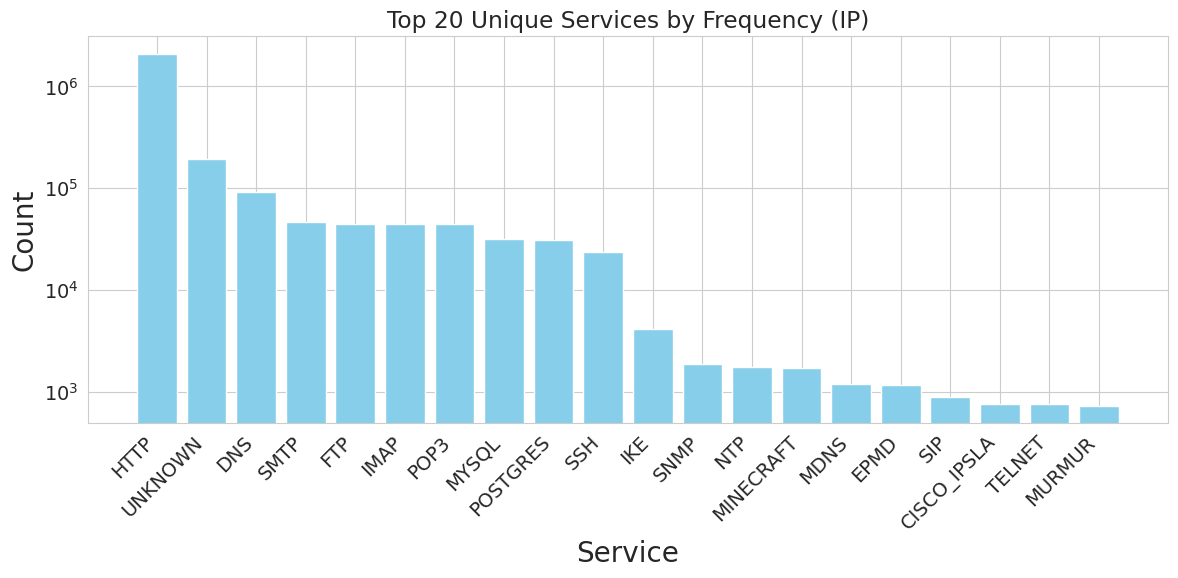

In [58]:
service_freq_unique_pd = service_freq_unique.limit(20).toPandas()
plt.figure(figsize=(12, 6))
plt.bar(service_freq_unique_pd["service"], service_freq_unique_pd["count"], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Service")
plt.ylabel("Count")
plt.yscale('log')
plt.title("Top 20 Unique Services by Frequency (IP)")
plt.tight_layout()
plt.show()

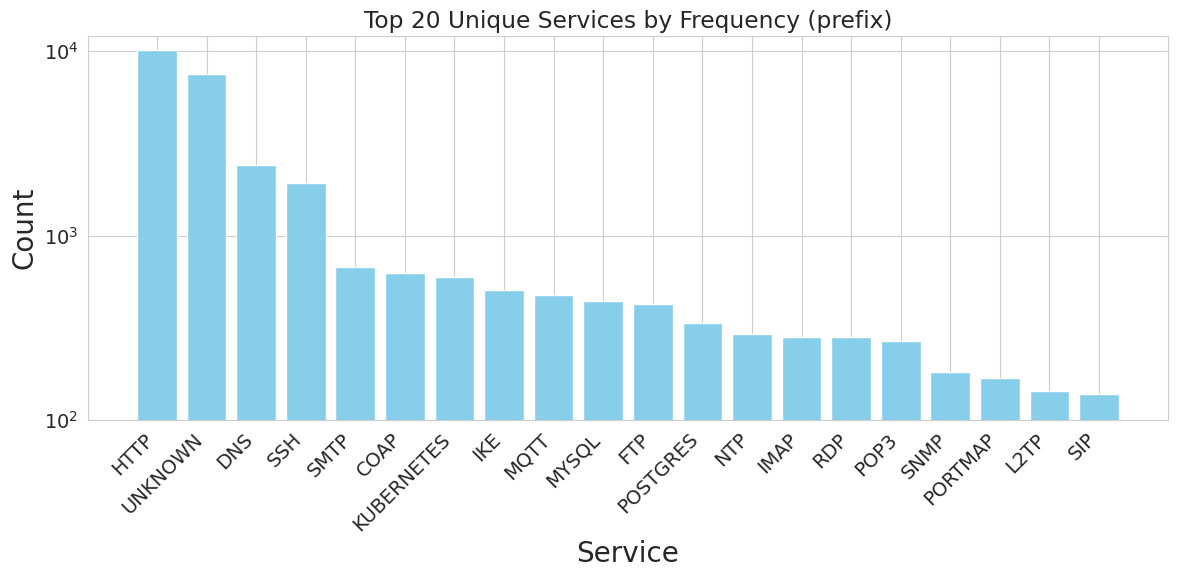

In [59]:
service_freq_unique_pd = service_freq_prefix.limit(20).toPandas()
plt.figure(figsize=(12, 6))
plt.bar(service_freq_unique_pd["service"], service_freq_unique_pd["count"], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Service")
plt.ylabel("Count")
# log
plt.yscale('log')

plt.ylim(100, 12_000)

plt.title("Top 20 Unique Services by Frequency (prefix)")
plt.tight_layout()
plt.show()

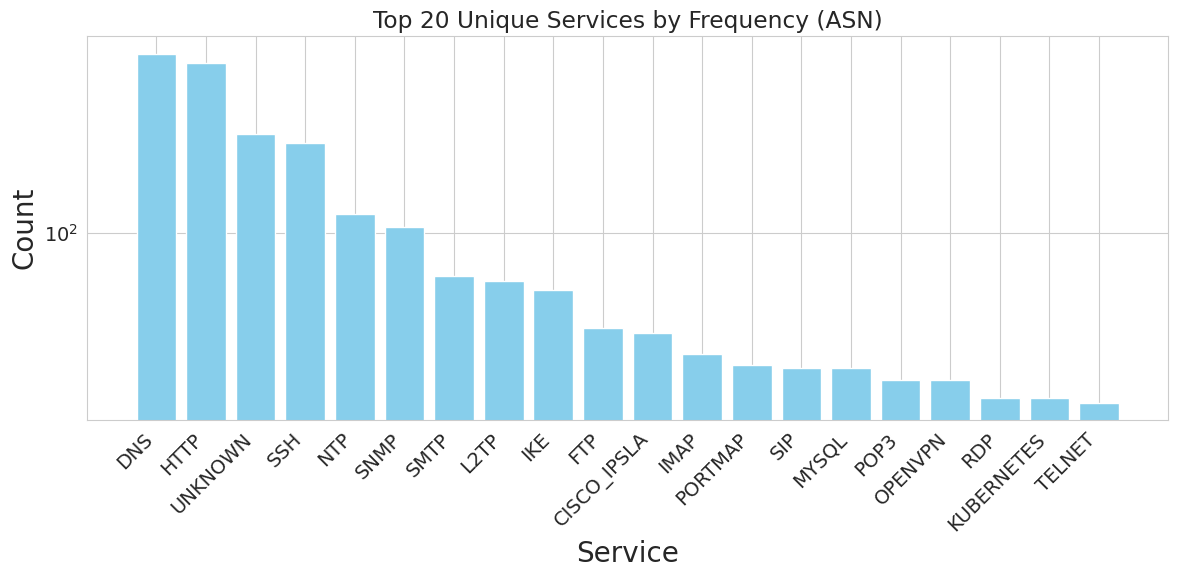

In [60]:
service_freq_unique_pd = service_freq_as.limit(20).toPandas()
plt.figure(figsize=(12, 6))
plt.bar(service_freq_unique_pd["service"], service_freq_unique_pd["count"], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Service")
plt.ylabel("Count")
# log
plt.yscale('log')

#plt.ylim(100, 12_000)

plt.title("Top 20 Unique Services by Frequency (ASN)")
plt.tight_layout()
plt.show()

In [62]:
# combine top services by IP, prefix, AS into one df for plotting

# top 20 services by IP
df_ip = service_freq_unique.limit(20).toPandas()
df_ip = df_ip.rename(columns={"count": "IPs"})

# get stats for prefixes and ASNs
df_prefix = service_freq_prefix.toPandas().rename(columns={"count": "Prefixes"})
df_as = service_freq_as.toPandas().rename(columns={"count": "ASNs"})

# merge into one df
merged_df = df_ip.merge(df_prefix, on="service", how="left") \
                 .merge(df_as, on="service", how="left")

# handle NaNs
merged_df = merged_df.fillna(0)

# From: [Service, IPs, Prefixes, ASNs]
# To:   [Service, Metric, Count]
plot_data = merged_df.melt(
    id_vars="service", 
    value_vars=["IPs", "Prefixes", "ASNs"],
    var_name="Metric", 
    value_name="Count"
)

merged_df

,service,IPs,Prefixes,percentage_x,ASNs,percentage_y
0,HTTP,2087197,10161,86.697952,435,61.354020
1,UNKNOWN,194911,7543,64.360068,236,33.286319
2,DNS,90976,2397,20.452218,471,66.431594
3,SMTP,46985,677,5.776451,69,9.732017
4,FTP,44692,424,3.617747,44,6.205924
5,IMAP,44455,282,2.406143,35,4.936530
6,POP3,44435,269,2.295222,28,3.949224
7,MYSQL,31364,443,3.779863,31,4.372355
8,POSTGRES,31111,338,2.883959,12,1.692525
9,SSH,23770,1932,16.484642,218,30.747532


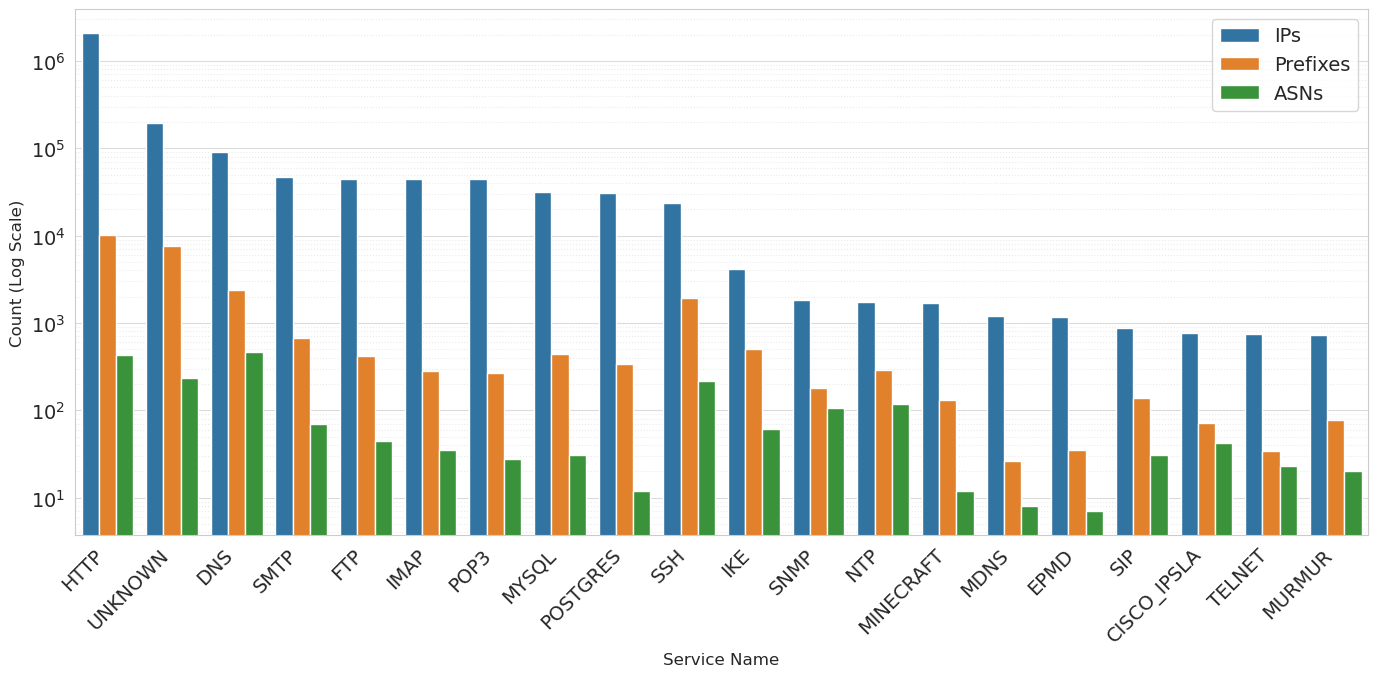

In [64]:
# plot combined results

plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# bar plot
ax = sns.barplot(
    data=plot_data, 
    x="service", 
    y="Count", 
    hue="Metric", # creates side-by-side bars
    palette=["#1f77b4", "#ff7f0e", "#2ca02c"] # Blue, Orange, Green
)

# log scale
plt.yscale('log')

# 2. Title and Labels
plt.xlabel("Service Name", fontsize=12)
plt.ylabel("Count (Log Scale)", fontsize=12)
plt.xticks(rotation=45, ha='right')

# grid
plt.grid(True, which="major", axis="y", linestyle='-', alpha=0.7)
plt.grid(True, which="minor", axis="y", linestyle=':', alpha=0.4)

plt.legend()
plt.tight_layout()

plt.show()

In [ ]:
# TODO make above plot for 'Hypergiant' and 'non-Hypergiant'

In [74]:
# ASes deploying NTP
ntp_as_stats = censys_anycast_df \
    .filter(F.array_contains("service_name", "NTP")) \
    .groupBy("autonomous_system.asn", "autonomous_system.name") \
    .agg(
        # /24s
        F.countDistinct("prefix").alias("/24s"),
        
        # active IPs
        F.countDistinct("host_identifier").alias("IPs")
    ) \
    .orderBy(F.col("IPs").desc())

print(f"Total ASNs providing NTP: {ntp_as_stats.count()}")

ntp_as_stats.show(100, truncate=False)

Total ASNs providing NTP: 118
+------+----------------------------------------------------------+----+---+
|asn   |name                                                      |/24s|IPs|
+------+----------------------------------------------------------+----+---+
|41992 |SI2                                                       |2   |511|
|20057 |ATT-MOBILITY-LLC-AS20057                                  |1   |253|
|29789 |REFLECTED                                                 |2   |124|
|16509 |AMAZON-02                                                 |115 |122|
|60952 |CONNEXCS                                                  |2   |117|
|62642 |BIGLEAF                                                   |2   |92 |
|18119 |ACSDATA-NZ ACSData                                        |1   |40 |
|15557 |LDCOMNET --- I3Dnet ---                                   |1   |28 |
|6079  |RCN-AS                                                    |1   |21 |
|29067 |UATLD-AS UA ccTLD Manager             

In [76]:
ntp_ases = censys_anycast_df \
    .filter(F.array_contains("service_name", "MURMUR")) \
    .groupBy("autonomous_system.asn", "autonomous_system.name") \
    .agg(
        # /24s
        F.countDistinct("prefix").alias("/24s"),
        
        # active IPs
        F.countDistinct("host_identifier").alias("IPs")
    ) \
    .orderBy(F.col("IPs").desc())

print(f"Total ASNs providing service: {ntp_ases.count()}")

ntp_ases.show(100, truncate=False)

Total ASNs providing service: 20
+------+----------------------------------------------+----+---+
|asn   |name                                          |/24s|IPs|
+------+----------------------------------------------+----+---+
|23393 |NUCDN                                         |7   |459|
|204903|COLLINIGROUP                                  |2   |134|
|45102 |ALIBABA-CN-NET Alibaba US Technology Co., Ltd.|1   |56 |
|8068  |MICROSOFT-CORP-MSN-AS-BLOCK                   |23  |29 |
|8075  |MICROSOFT-CORP-MSN-AS-BLOCK                   |19  |24 |
|36351 |SOFTLAYER                                     |4   |4  |
|3549  |LVLT-3549                                     |4   |4  |
|40509 |FLY                                           |2   |2  |
|57926 |SAFEDNS-AS                                    |1   |2  |
|3356  |LEVEL3                                        |2   |2  |
|16509 |AMAZON-02                                     |2   |2  |
|11404 |AS-WAVE-1                                     |2 

In [78]:
ntp_ases = censys_anycast_df \
    .filter(F.array_contains("service_name", "MINECRAFT")) \
    .groupBy("autonomous_system.asn", "autonomous_system.name") \
    .agg(
        # /24s
        F.countDistinct("prefix").alias("/24s"),
        
        # active IPs
        F.countDistinct("host_identifier").alias("IPs")
    ) \
    .orderBy(F.col("IPs").desc())

print(f"Total ASNs providing anycasted minecraft: {ntp_ases.count()}")

ntp_ases.show(100, truncate=False)

Total ASNs providing anycasted minecraft: 12
+------+------------------------------------------+----+---+
|asn   |name                                      |/24s|IPs|
+------+------------------------------------------+----+---+
|30456 |COSMIC-GLOBAL                             |2   |511|
|64199 |TCPSHIELD                                 |2   |509|
|199414|NEOPROTECT-NET NeoProtect                 |5   |471|
|13335 |CLOUDFLARENET                             |81  |142|
|400519|PLAYIT-GG                                 |6   |40 |
|40509 |FLY                                       |21  |22 |
|16509 |AMAZON-02                                 |9   |9  |
|136165|X4B-AS-AP X4B DDoS Protected Announcements|1   |4  |
|17551 |ANYCAST-AS-AP Anycast Global Backbone     |2   |2  |
|19551 |INCAPSULA                                 |1   |1  |
|149026|EMUTELPTYLTD-AS-AP EmuTel                 |1   |1  |
|53667 |PONYNET                                   |1   |1  |
+------+--------------------------------

In [96]:
# Asn 13335 corresponds to Cloudflare
service_cloudflare = censys_anycast_df \
    .filter(psf.col("autonomous_system.asn") == 13335) \
    .select("host_identifier.ipv4", psf.array_distinct("service_name").alias("unique_services")) \
    .select(psf.explode("unique_services").alias("service")) \
    .groupBy("service") \
    .count() \
    .orderBy("count", ascending=False)

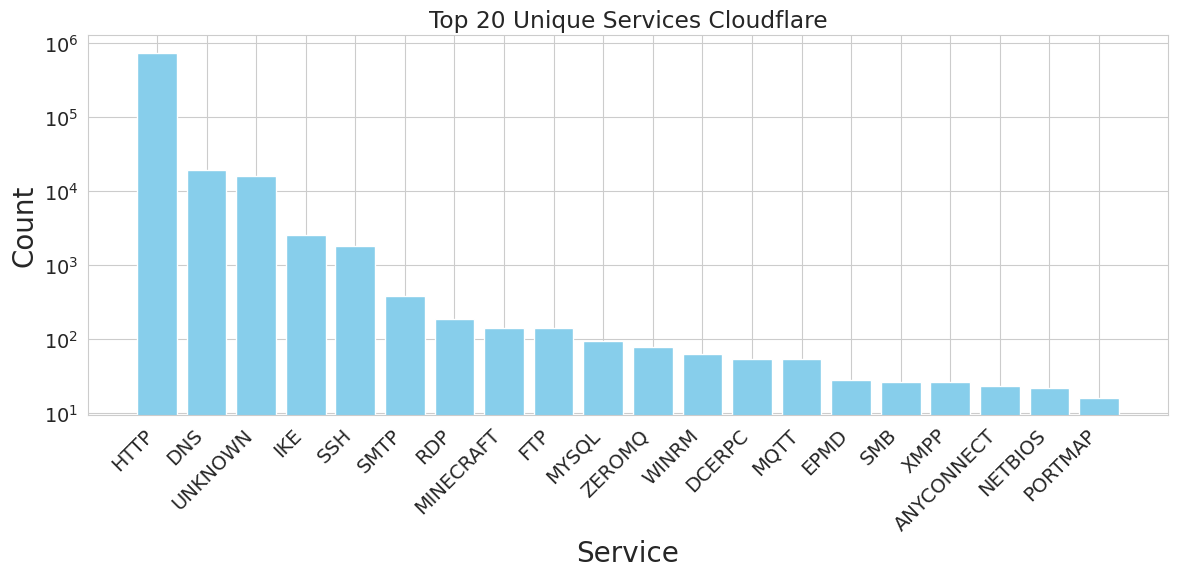

In [98]:
service_cloudflare_pd = service_cloudflare.limit(20).toPandas()
plt.figure(figsize=(12, 6))
plt.bar(service_cloudflare_pd["service"], service_cloudflare_pd["count"], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Service")
plt.ylabel("Count")
plt.yscale('log')
plt.title("Top 20 Unique Services Cloudflare")
plt.tight_layout()
plt.show()

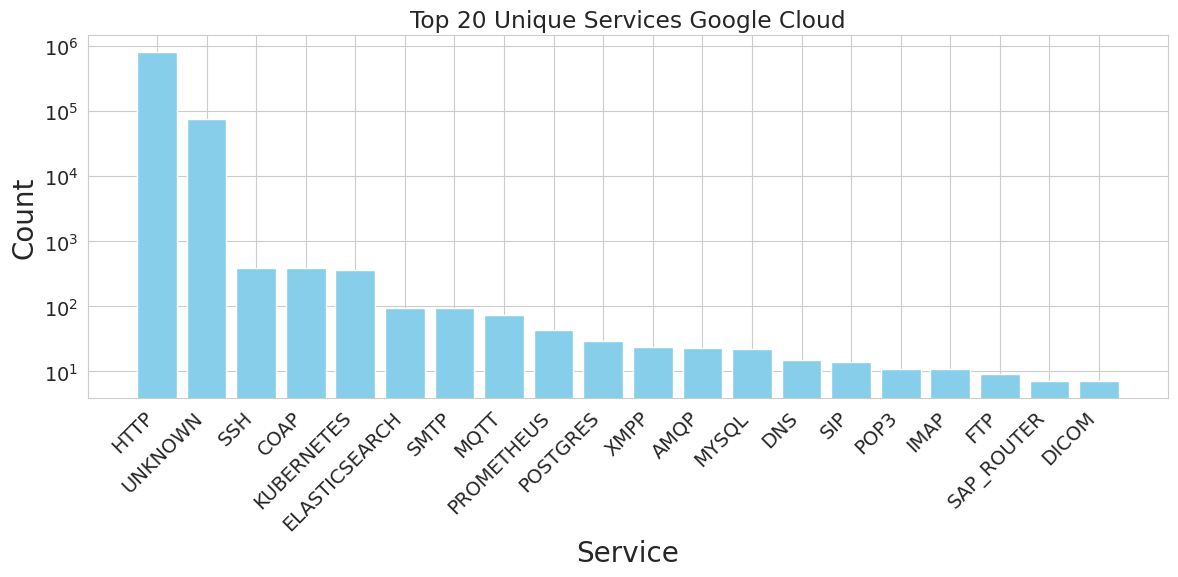

In [99]:
service_google = censys_anycast_df \
    .filter(psf.col("autonomous_system.asn") == 396982) \
    .select("host_identifier.ipv4", psf.array_distinct("service_name").alias("unique_services")) \
    .select(psf.explode("unique_services").alias("service")) \
    .groupBy("service") \
    .count() \
    .orderBy("count", ascending=False)

service_google_pd = service_google.limit(20).toPandas()
plt.figure(figsize=(12, 6))
plt.bar(service_google_pd["service"], service_google_pd["count"], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Service")
plt.ylabel("Count")
plt.yscale('log')
plt.title("Top 20 Unique Services Google Cloud")
plt.tight_layout()
plt.show()

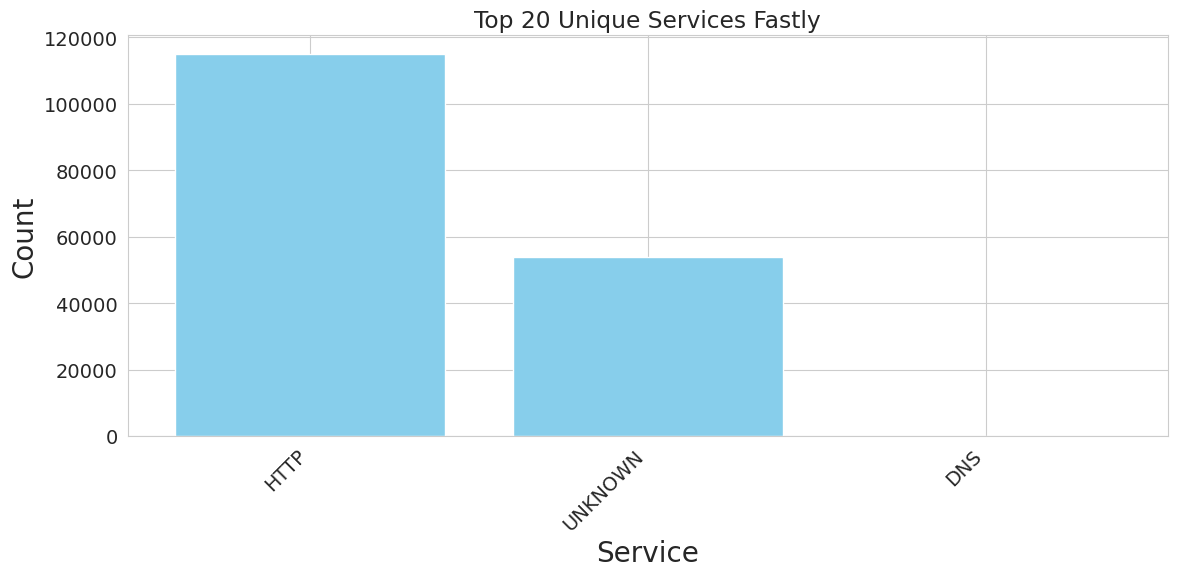

In [102]:
service_fastly = censys_anycast_df \
    .filter(psf.col("autonomous_system.asn") == 54113) \
    .select("host_identifier.ipv4", psf.array_distinct("service_name").alias("unique_services")) \
    .select(psf.explode("unique_services").alias("service")) \
    .groupBy("service") \
    .count() \
    .orderBy("count", ascending=False)

service_fastly_pd = service_fastly.limit(20).toPandas()
plt.figure(figsize=(12, 6))
plt.bar(service_fastly_pd["service"], service_fastly_pd["count"], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Service")
plt.ylabel("Count")
plt.title("Top 20 Unique Services Fastly")
plt.tight_layout()
plt.show()

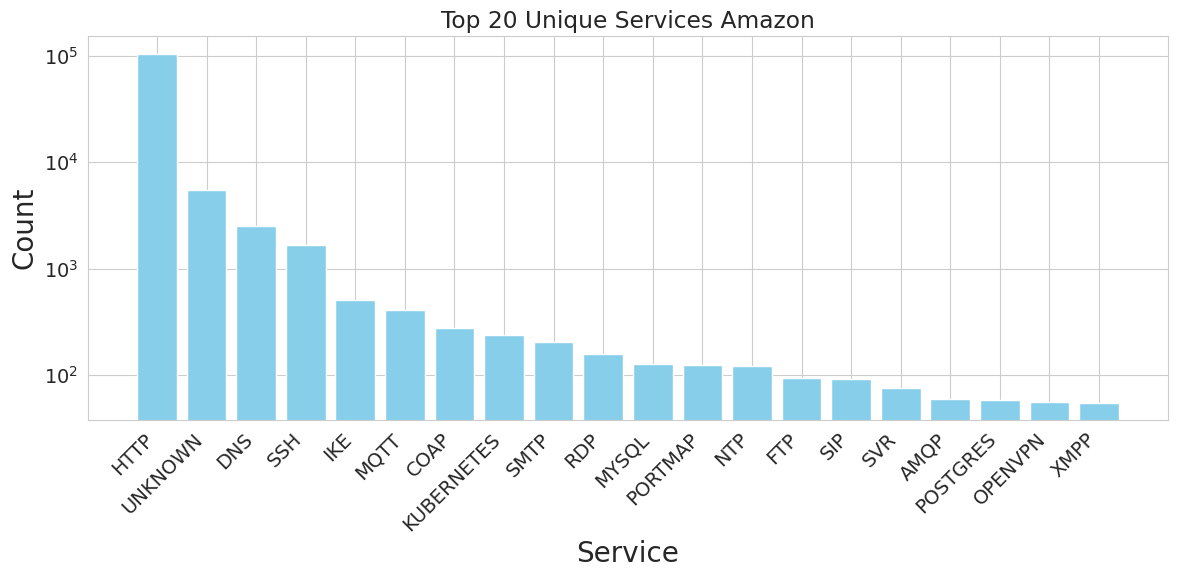

In [103]:
service_amazon = censys_anycast_df \
    .filter(psf.col("autonomous_system.asn") == 16509) \
    .select("host_identifier.ipv4", psf.array_distinct("service_name").alias("unique_services")) \
    .select(psf.explode("unique_services").alias("service")) \
    .groupBy("service") \
    .count() \
    .orderBy("count", ascending=False)

service_amazon_pd = service_amazon.limit(20).toPandas()
plt.figure(figsize=(12, 6))
plt.bar(service_amazon_pd["service"], service_amazon_pd["count"], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Service")
plt.ylabel("Count")
plt.yscale('log')

plt.title("Top 20 Unique Services Amazon")
plt.tight_layout()
plt.show()

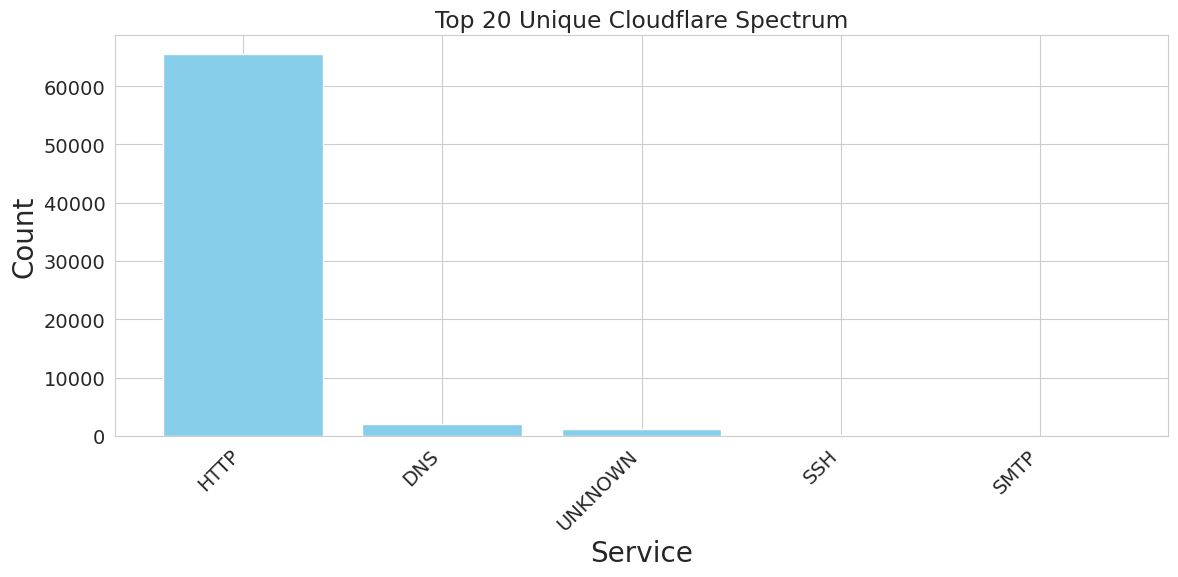

In [104]:
service_cloudflarespec = censys_anycast_df \
    .filter(psf.col("autonomous_system.asn") == 209242) \
    .select("host_identifier.ipv4", psf.array_distinct("service_name").alias("unique_services")) \
    .select(psf.explode("unique_services").alias("service")) \
    .groupBy("service") \
    .count() \
    .orderBy("count", ascending=False)

service_cloudflarespec_pd = service_cloudflarespec.limit(20).toPandas()
plt.figure(figsize=(12, 6))
plt.bar(service_cloudflarespec_pd["service"], service_cloudflarespec_pd["count"], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Service")
plt.ylabel("Count")
plt.title("Top 20 Unique Cloudflare Spectrum")
plt.tight_layout()
plt.show()

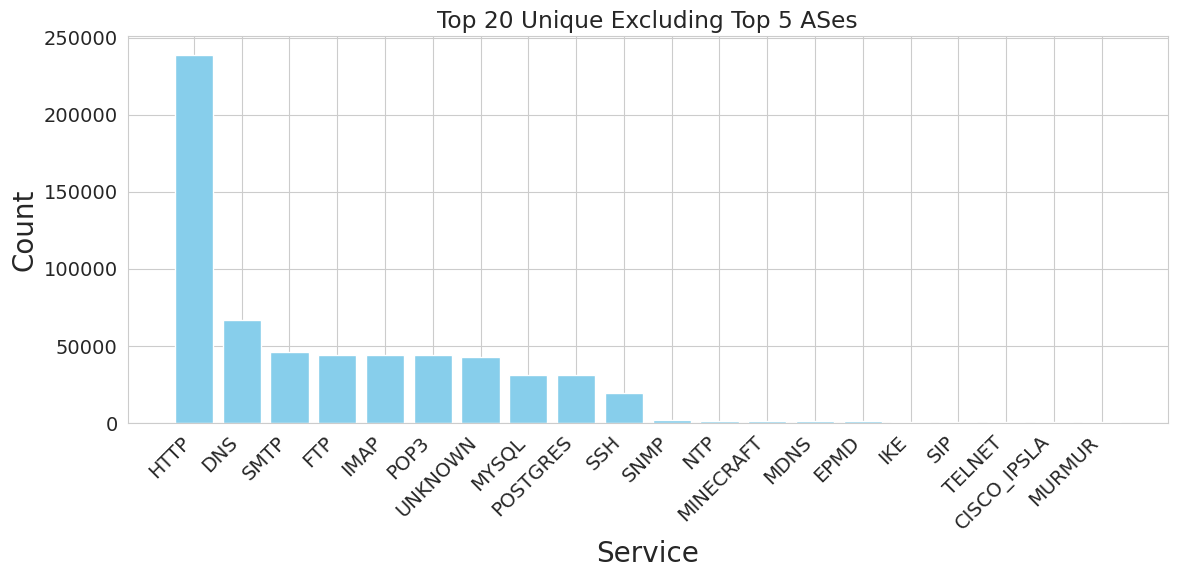

In [105]:
excluded_asns = [396982, 13335, 54113, 16509, 209242]

service_other = censys_anycast_df \
    .filter(~psf.col("autonomous_system.asn").isin(excluded_asns)) \
    .select("host_identifier.ipv4", psf.array_distinct("service_name").alias("unique_services")) \
    .select(psf.explode("unique_services").alias("service")) \
    .groupBy("service") \
    .count() \
    .orderBy("count", ascending=False)

service_other_pd = service_other.limit(20).toPandas()
plt.figure(figsize=(12, 6))
plt.bar(service_other_pd["service"], service_other_pd["count"], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Service")
plt.ylabel("Count")
plt.title("Top 20 Unique Excluding Top 5 ASes")
plt.tight_layout()
plt.show()

### Now that the top 5 CDNs are filtered out, the data is a lot more significant. HTTP still dominates over the other services, however we can see how the other services are distributed

In [ ]:
# Define Top 5 ASNs
top5_asns = [396982, 13335, 54113, 16509, 209242]

# Step 1: Label entries as Top 5 vs Other, explode services
exploded_df = (
    censys_anycast_df
    .withColumn("group", psf.when(psf.col("autonomous_system.asn").isin(top5_asns), "Top 5 ASes").otherwise("Other ASes"))
    .withColumn("service", psf.explode("service_name"))
    .filter(psf.col("service") != "UNKNOWN")
    .select("group", "service", "host_identifier.ipv4")
)

# Step 2: Group by service and group, count unique IPs
service_grouped = (
    exploded_df
    .groupBy("service", "group")
    .agg(psf.countDistinct("ipv4").alias("ip_count"))
)

# Step 3: Get top 20 services by total IP count
top_services_df = (
    service_grouped
    .groupBy("service")
    .agg(psf.sum("ip_count").alias("total_ip_count"))
    .orderBy(psf.desc("total_ip_count"))
    .limit(20)
    .select("service")  # Just get the service names
)

# Step 4: Join back to filter original grouped data to top 20 only
top_services = service_grouped.join(top_services_df, on="service", how="inner")

# Step 5: Convert to Pandas for plotting
top_services_pd = top_services.toPandas()

In [ ]:
# Pivot the DataFrame: rows are services, columns are groups ("Top 5 ASes", "Other ASes")
pivot_df = top_services_pd.pivot(index="service", columns="group", values="ip_count").fillna(0)

# Sort by total IP count (Top 5 + Other)
pivot_df["Total"] = pivot_df.sum(axis=1)
pivot_df = pivot_df.sort_values(by="Total", ascending=False).drop(columns="Total")

# Plot
ax = pivot_df.plot(kind="bar", figsize=(14, 6), color=["skyblue", "salmon"])
ax.set_yscale("log")
plt.title("Top 20 Services by Unique IPs: Top 5 ASes vs Other ASes")
plt.ylabel("Unique IP Count (log)")
ax.set_xlabel("")
plt.xticks(rotation=45, ha='right')
plt.legend(title="AS Group")
plt.tight_layout()
plt.savefig("output/tp_service_comparison.pdf", bbox_inches='tight')
plt.show()

SSH is a misconfig  due to laziness. The services deployed for the unicast addresses are also accessible in the anycast addresses. Default kernel behaviour is the speculation.
Look into minecraft anycast
Telnet is old and not secure, top 5 likely already replaced it

In [ ]:
pivot = top_services_pd.pivot(index='service', columns='group', values='ip_count')
print(pivot.head(20))

# Analyzing the ports that services are deployed on

In [ ]:
port_freq = censys_anycast.select(psf.explode("port").alias("ports")
                                    ).groupBy("ports").count().orderBy("count", ascending=False)

port_freq.show(10, truncate=False)

In [ ]:
port_freq_pd = port_freq.limit(20).toPandas()
plt.figure(figsize=(12, 6))
plt.bar(port_freq_pd["ports"].astype(str), port_freq_pd["count"], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Port")
plt.ylabel("Count")
plt.title("Top 20 Open Ports by Count")
plt.tight_layout()
plt.show()

### 443 is the most used port, most likely due to the large amount of HTTP deployed. The group of ports that have similar counts are likely due to CDNs deploying over them on every IP 

Figure out how nmap works to explain why they find more services than I do

In [ ]:
print(f"Total distinct ports: {port_freq.count()}")

In [ ]:
# 172.65.64.119 has a very large number of services

censys_anycast.filter(
    psf.array_contains("port", 58000)
).select("host_identifier.ipv4", "port").show(truncate=True)

In [ ]:
censys_anycast \
    .filter(censys_anycast["host_identifier.ipv4"] == "172.65.64.119") \
    .select("host_identifier.ipv4", psf.size("service_name").alias("service_count")) \
    .show()
print("Distinct services")
censys_anycast \
    .filter(censys_anycast["host_identifier.ipv4"] == "172.65.64.119") \
    .select("host_identifier.ipv4", psf.size(psf.array_distinct("service_name")).alias("service_count")) \
    .show()

# Aggregating services and IPs per /24 prefix

In [ ]:
# Adds up all the distinct services of all the IPs per prefix, and keeps count of how many IPs exist in that prefix with ip_count
aggregated = censys_anycast.select(
    "prefix",
    psf.col("host_identifier.ipv4").alias("ipv4"),
    psf.col("autonomous_system.asn").alias("asn"),
    psf.explode(
        psf.array_distinct("service_name")
    ).alias("service")
).groupBy("prefix").agg(
    psf.collect_set("service").alias("distinct_services"),
    psf.countDistinct("ipv4").alias("ip_count"),
    psf.collect_set("asn").alias("asn_set")
).persist(StorageLevel.MEMORY_AND_DISK)


In [ ]:
aggregated.show(50, truncate=False)

In [ ]:
aggregated.filter(aggregated["ip_count"] == 5).show(truncate=False)

In [ ]:
# Filter if data about a specific prefix is needed
aggregated.filter(aggregated["prefix"] == "1.2.3.0/24").show(truncate=False)

In [ ]:
# Adds a column to the bins so that the plotted chart is in the correct order.
def get_ip_bin_counts(df):
    binned = df.withColumn(
        "ip_bin",
        psf.when(df.ip_count == 256, "256")
        .when(df.ip_count == 1, "1")
        .when((df.ip_count > 1) & (df.ip_count <= 50), "2-50")
        .when((df.ip_count > 50) & (df.ip_count <= 150), "51-150")
        .when((df.ip_count > 150) & (df.ip_count < 256), "151-255")
    )

    # Add bin_order to binned so it can be used later
    binned = binned.withColumn(
        "bin_order",
        psf.when(psf.col("ip_bin") == "256", 0)
        .when(psf.col("ip_bin") == "151-255", 1)
        .when(psf.col("ip_bin") == "51-150", 2)
        .when(psf.col("ip_bin") == "2-50", 3)
        .when(psf.col("ip_bin") == "1", 4)
    )

    # Count occurrences per bin
    bin_counts = binned.groupBy("ip_bin", "bin_order").count()

    return bin_counts.orderBy("bin_order")

In [ ]:
ip_bin_counts_pd = get_ip_bin_counts(aggregated).toPandas()

plt.figure(figsize=(8, 5))
plt.bar(ip_bin_counts_pd["ip_bin"], ip_bin_counts_pd["count"], color='skyblue')
plt.xlabel("IP Count Bin")
plt.ylabel("Number of /24 Prefixes")
plt.title("Distribution of IP Counts per /24 Prefix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Very important graph, shows that a majority of prefixes utilize most/every IP address within them. Likely done due to a lazy deployment.

In [ ]:
print("Total in bins: ", ip_bin_counts.agg(psf.sum("count")).collect()[0][0])
print("Total prefixes: ", aggregated.count())

In [ ]:
aggregated.filter((psf.col("ip_count") >= 151) & (psf.col("ip_count") < 256)).count()

In [ ]:
aggregated.filter(psf.col("ip_count") >= 5).count()

In [ ]:
# Finding how many AS'es have 5 or more IPs, for comparison with old study
aggregated.filter(psf.col("ip_count") >= 5) \
          .select(psf.explode("asn_set").alias("asn")) \
          .distinct() \
          .count()

In [ ]:
aggregated.filter(psf.array_contains("asn_set", 396982)).count() # Number of /24 by google 

In [ ]:
censys_anycast \S # Checking a spesific prefix for MYSQL
    .filter((psf.col("prefix") == "85.128.147.0/24") & psf.array_contains("service_name", "MYSQL")) \
    .select("host_identifier.ipv4", "service_name") \
    .show(truncate=False)

In [ ]:
ip_count_distribution = aggregated.groupBy("ip_count").count().orderBy("ip_count")
ip_count_distribution.show(220, truncate=False)

In [ ]:
aggregated_cloudflare = aggregated.filter(psf.array_contains("asn_set", 13335))
bins_cloudflare_pd = get_ip_bin_counts(aggregated_cloudflare).toPandas()

plt.figure(figsize=(8, 5))
plt.bar(bins_cloudflare_pd["ip_bin"], bins_cloudflare_pd["count"], color='skyblue')
plt.xlabel("IP Count Bin")
plt.ylabel("Number of /24 Prefixes")
plt.title("Distribution of IP Counts per /24 Prefix Cloudflare")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
aggregated_google = aggregated.filter(psf.array_contains("asn_set", 396982))
bins_google_pd = get_ip_bin_counts(aggregated_google).toPandas()

plt.figure(figsize=(8, 5))
plt.bar(bins_google_pd["ip_bin"], bins_google_pd["count"], color='skyblue')
plt.xlabel("IP Count Bin")
plt.ylabel("Number of /24 Prefixes")
plt.title("Distribution of IP Counts per /24 Prefix Google")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
aggregated_fastly = aggregated.filter(psf.array_contains("asn_set", 54113))
bins_fastly_pd = get_ip_bin_counts(aggregated_fastly).toPandas()

plt.figure(figsize=(8, 5))
plt.bar(bins_fastly_pd["ip_bin"], bins_fastly_pd["count"], color='skyblue')
plt.xlabel("IP Count Bin")
plt.ylabel("Number of /24 Prefixes")
plt.title("Distribution of IP Counts per /24 Prefix Fastly")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
aggregated_amazon = aggregated.filter(psf.array_contains("asn_set", 16509))
bins_amazon_pd = get_ip_bin_counts(aggregated_amazon).toPandas()

plt.figure(figsize=(8, 5))
plt.bar(bins_amazon_pd["ip_bin"], bins_amazon_pd["count"], color='skyblue')
plt.xlabel("IP Count Bin")
plt.ylabel("Number of /24 Prefixes")
plt.title("Distribution of IP Counts per /24 Prefix Amazon")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
aggregated_cloudflarespec = aggregated.filter(psf.array_contains("asn_set", 209242))
bins_cloudflarespec_pd = get_ip_bin_counts(aggregated_cloudflarespec).toPandas()

plt.figure(figsize=(8, 5))
plt.bar(bins_cloudflarespec_pd["ip_bin"], bins_cloudflarespec_pd["count"], color='skyblue')
plt.xlabel("IP Count Bin")
plt.ylabel("Number of /24 Prefixes")
plt.title("Distribution of IP Counts per /24 Prefix Cloudflare Spectrum")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
excluded_asns = [396982, 13335, 54113, 16509, 209242]

filtered_df = aggregated
for asn in excluded_asns:
    filtered_df = filtered_df.filter(~psf.array_contains("asn_set", asn))

bins_filtered_pd = get_ip_bin_counts(filtered_df).toPandas()

plt.figure(figsize=(8, 5))
plt.bar(bins_filtered_pd["ip_bin"], bins_filtered_pd["count"], color='skyblue')
plt.xlabel("IP Count Bin")
plt.ylabel("Number of /24 Prefixes")
plt.title("Distribution of IP Counts per /24 Prefix Excluding the Top 5 Ases")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
bin_order = ["256", "151-255", "51-150", "2-50", "1"]

# Combine the top 5 into one dataframe
top5_df = pd.concat([
    bins_cloudflare_pd,
    bins_google_pd,
    bins_fastly_pd,
    bins_amazon_pd,
    bins_cloudflarespec_pd
])

# Sum counts per bin for each group
top5_grouped = top5_df.groupby('ip_bin')['count'].sum().reset_index()
top5_grouped['group'] = 'Top 5 ASes'

non_top5_grouped = bins_filtered_pd.groupby('ip_bin')['count'].sum().reset_index()
non_top5_grouped['group'] = 'Other ASes'

# Combine both groups
combined = pd.concat([top5_grouped, non_top5_grouped])

# Ensure ip_bin is ordered correctly
combined['ip_bin'] = pd.Categorical(combined['ip_bin'], categories=bin_order, ordered=True)

# Pivot for plotting with actual counts
pivot_df = combined.pivot(index='ip_bin', columns='group', values='count').fillna(0)
pivot_df = pivot_df.sort_index()

# Plot
ax = pivot_df.plot(kind='bar', figsize=(10, 6), width=0.75, color=['salmon', 'skyblue'])
ax.tick_params(labelsize=18)
plt.ylabel("Number of /24 Prefixes")
plt.xlabel("Number of Unique IPs per /24 Prefix (Binned)")
plt.title("IP Count Distribution per /24 Prefix: Top 5 ASes vs Other ASes")
plt.legend(title="AS Group")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("output/IP_Count_dist.pdf", bbox_inches='tight')
plt.show()

# Checking how many http titles per prefix are unique

In [ ]:
http_titles_per_prefix = censys_anycast \
    .filter(psf.array_contains("port", 443)) \
    .filter(psf.col("headers").isNotNull()) \
    .groupBy("prefix") \
    .agg(psf.countDistinct("headers").alias("unique_http_headers"))

In [ ]:
http_titles_per_prefix.filter(psf.col("prefix") == "172.65.64.0/24").show(truncate=False)

In [ ]:
header_diversity_distribution = http_titles_per_prefix \
    .groupBy("unique_http_headers") \
    .count() \
    .orderBy("unique_http_headers")

header_diversity_distribution.show(220, truncate=False)

In [ ]:
# plot using a CDF
header_distribution_pd = header_diversity_distribution.toPandas()
header_distribution_pd["cdf"] = header_distribution_pd["count"].cumsum() / header_distribution_pd["count"].sum()

plt.figure(figsize=(10, 6))
plt.plot(header_distribution_pd["unique_http_headers"], header_distribution_pd["cdf"], linestyle='-', marker=None)
plt.title("CDF of Unique HTTP Headers")
plt.xlabel("Unique HTTP Headers")
plt.ylabel("CDF")
plt.grid(True)
plt.show()

In [ ]:
distinct_levels = header_diversity_distribution.select("unique_http_headers").distinct().count()
print(f"Number of unique header diversity levels: {distinct_levels}")

# Plotting services after aggregating by unique per prefix

<span style="color:red">Comparison graphs from here on will require the corresponding AS graph from the service analysis section to be run</span>

In [ ]:
def plot_service_comparison(aggregated_dist_pd, ip_df_pd, asn_label="Unknown ASN"):
    org_name = asn_label.split(" (ASN")[0].replace(' ', '_')

    
    
    # Find common services
    common_services = list(set(aggregated_dist_pd["service"]) & set(ip_df_pd["service"]))

    # Filter and align
    prefix_df = aggregated_dist_pd[aggregated_dist_pd["service"].isin(common_services)].copy()
    count_df = ip_df_pd[ip_df_pd["service"].isin(common_services)].copy() # this is for unique ips

    # Merge to align by service
    merged_df = prefix_df.merge(count_df, on="service", suffixes=('_prefix', '_count'))

    merged_df = merged_df.sort_values("count_count", ascending=False).head(10)

    # Plot
    fig, ax = plt.subplots(figsize=(14, 6))
    bar_width = 0.4
    x = np.arange(len(merged_df))

    ax.bar(x - bar_width/2, merged_df["count_prefix"], width=bar_width, label="Prefixes", color='skyblue')
    ax.bar(x + bar_width/2, merged_df["count_count"], width=bar_width, label="Unique IPs", color='salmon')
    ax.set_yscale("log")
    ax.set_ylabel("Count (Log Scale)")
    ax.set_title(f"Service Spread vs. Density - {asn_label}")
    ax.set_xticks(x)
    ax.tick_params(labelsize=20)
    ax.set_xticklabels(merged_df["service"], rotation=45, ha='right')
    plt.legend()

    plt.savefig(f"output/{org_name}_service_dist.pdf", bbox_inches='tight')
    plt.show()

In [ ]:
aggregated_cloudflare = aggregated.filter(psf.array_contains("asn_set", 13335))
service_distribution_cf = aggregated_cloudflare \
    .withColumn("service", psf.explode("distinct_services")) \
    .filter("service != 'UNKNOWN'") \
    .groupBy("service") \
    .count() \
    .orderBy("count", ascending=False)

In [ ]:
dist_cf_pd = service_distribution_cf.limit(20).toPandas()
plt.figure(figsize=(10, 5))
plt.bar(dist_cf_pd["service"], dist_cf_pd["count"], color='skyblue')
plt.xlabel("Service")
plt.ylabel("Number of Prefixes")
plt.title("Services Deployed by Cloudflare Per Prefix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# As a reminder, service_cloudflare_pd is from the Service Analysis section, where the top 20 services deployed by cloudflare are found
plot_service_comparison(dist_cf_pd, service_cloudflare_pd, asn_label="Cloudflare (ASN 13335)")

IKE likely used for DDos protection by cloudflare magic transit - hypothesis + future work

In [ ]:
aggregated_google = aggregated.filter(psf.array_contains("asn_set", 396982)) # Google Cloud
service_distribution_gc = aggregated_google \
    .withColumn("service", psf.explode("distinct_services")) \
    .filter("service != 'UNKNOWN'") \
    .groupBy("service") \
    .count() \
    .orderBy("count", ascending=False)

In [ ]:
dist_gc_pd = service_distribution_gc.limit(20).toPandas()
plt.figure(figsize=(10, 5))
plt.bar(dist_gc_pd["service"], dist_gc_pd["count"], color='skyblue')
plt.xlabel("Service")
plt.ylabel("Number of Prefixes")
plt.title("Services Deployed by Google Cloud Per Prefix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
plot_service_comparison(dist_gc_pd,service_google_pd, asn_label="Google Cloud (ASN 396982)")

In [ ]:
aggregated_fastly = aggregated.filter(psf.array_contains("asn_set", 54113)) # Fastly
service_distribution_fa = aggregated_fastly \
    .withColumn("service", psf.explode("distinct_services")) \
    .filter("service != 'UNKNOWN'") \
    .groupBy("service") \
    .count() \
    .orderBy("count", ascending=False)

In [ ]:
dist_fa_pd = service_distribution_fa.limit(20).toPandas()
plt.figure(figsize=(10, 5))
plt.bar(dist_fa_pd["service"], dist_fa_pd["count"], color='skyblue')
plt.xlabel("Service")
plt.ylabel("Number of Prefixes")
plt.title("Services Deployed by Fastly Per Prefix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
plot_service_comparison(dist_fa_pd,service_fastly_pd, asn_label="Fastly (ASN 54113)")

In [ ]:
aggregated_amazon = aggregated.filter(psf.array_contains("asn_set", 16509)) # Amazon
service_distribution_am = aggregated_amazon \
    .withColumn("service", psf.explode("distinct_services")) \
    .filter("service != 'UNKNOWN'") \
    .groupBy("service") \
    .count() \
    .orderBy("count", ascending=False)

In [ ]:
dist_am_pd = service_distribution_am.limit(20).toPandas()
plt.figure(figsize=(10, 5))
plt.bar(dist_am_pd["service"], dist_am_pd["count"], color='skyblue')
plt.xlabel("Service")
plt.ylabel("Number of Prefixes")
plt.title("Services Deployed by Amazon Per Prefix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
plot_service_comparison(dist_am_pd,service_amazon_pd, asn_label="Amazon (ASN 16509)")

In [ ]:
aggregated_cloudflarespec = aggregated.filter(psf.array_contains("asn_set", 209242)) # Cloudflare Spectrum
service_distribution_cfs = aggregated_cloudflarespec \
    .withColumn("service", psf.explode("distinct_services")) \
    .filter("service != 'UNKNOWN'") \
    .groupBy("service") \
    .count() \
    .orderBy("count", ascending=False)

In [ ]:
dist_cfs_pd = service_distribution_cfs.limit(20).toPandas()
plt.figure(figsize=(10, 5))
plt.bar(dist_cfs_pd["service"], dist_cfs_pd["count"], color='skyblue')
plt.xlabel("Service")
plt.ylabel("Number of Prefixes")
plt.title("Services Deployed by Cloudflare Spectrum Per Prefix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
plot_service_comparison(dist_cfs_pd,service_cloudflarespec_pd, asn_label="Cloudflare Spectrum (ASN 209242)")

In [ ]:
dist_cf_pd["asn"] = "Cloudflare"
dist_gc_pd["asn"] = "Google"
dist_fa_pd["asn"] = "Fastly"
dist_am_pd["asn"] = "Amazon"
dist_cfs_pd["asn"] = "Cloudflare Spectrum"

# Combine all into one
combined = pd.concat([dist_cf_pd, dist_gc_pd, dist_fa_pd, dist_am_pd, dist_cfs_pd])

# Pivot to get service x ASN
pivot = combined.pivot_table(index="service", columns="asn", values="count", fill_value=0)

# Determine top 10 services by total count
top10_services = pivot.sum(axis=1).nlargest(10).index

# Filter to top 10
pivot_top = pivot.loc[top10_services]

# Normalize across rows (i.e., for each service, show AS contributions as %)
pivot_pct = pivot_top.div(pivot_top.sum(axis=1), axis=0) * 100


ax = pivot_pct.plot(
    kind="bar", stacked=True, figsize=(12, 6), colormap="tab20",
)
ax.legend_.remove()
ax.set_xlabel("")
plt.ylabel("Percentage of Deployment")
plt.title("Top 10 Anycast Services by Deployment Share per ASN")
plt.xticks(rotation=45, ha='right')
ax.tick_params(labelsize=20)


# Add bold percentage labels to segments >= 5%
for i, service in enumerate(pivot_pct.index):
    y_offset = 0
    for asn in pivot_pct.columns:
        height = pivot_pct.loc[service, asn]
        if height >= 5:
            ax.text(
                i, y_offset + height / 2,
                f"{height:.0f}%",
                ha='center', va='center',
                fontsize=11, fontweight='bold',
                path_effects=[
                    path_effects.Stroke(linewidth=3, foreground='white'),
                    path_effects.Normal()
                ]
            )
        y_offset += height

plt.savefig("output/top5_deployment.pdf", bbox_inches='tight')

plt.show()

In [ ]:
excluded_asns = [396982, 13335, 54113, 16509, 209242]

filtered_df_serv = aggregated
for asn in excluded_asns:
    filtered_df_serv = filtered_df_serv.filter(~psf.array_contains("asn_set", asn))

service_distribution_rest = filtered_df_serv \
    .withColumn("service", psf.explode("distinct_services")) \
    .filter("service != 'UNKNOWN'") \
    .groupBy("service") \
    .count() \
    .orderBy("count", ascending=False)

In [ ]:
dist_rest_pd = service_distribution_rest.limit(20).toPandas()
plt.figure(figsize=(10, 5))
plt.bar(dist_rest_pd["service"], dist_rest_pd["count"], color='skyblue')
plt.xlabel("Service")
plt.ylabel("Number of Prefixes")
plt.title("Services Deployed by ASes (Excluding the Top 5) Per Prefix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
plot_service_comparison(dist_rest_pd,service_other_pd, asn_label="ASes Not in the Top 5")

# Categorizing operators

In [ ]:
ip_location_df.printSchema()

In [ ]:
flattened_anycast = censys_anycast.withColumn("ipv4", psf.col("host_identifier.ipv4"))

enriched_anycast = flattened_anycast.join(
    ip_location_df.select("ip", "cc", "c_name", "isp", "usage_type"),
    psf.col("ipv4") == psf.col("ip"),
    how="left"
)

In [ ]:
enriched_anycast.printSchema()

In [ ]:
enriched_anycast.filter(psf.col("ipv4") == "2.18.50.76") \
    .select("ipv4", "cc", "c_name", "isp", "usage_type") \
    .show(truncate=False)

In [ ]:
enriched_anycast.groupBy("usage_type").count().orderBy("count", ascending=False).show(truncate=False)

In [ ]:
enriched_anycast \
    .select("usage_type", "autonomous_system.asn") \
    .distinct() \
    .groupBy("usage_type") \
    .count() \
    .orderBy("count", ascending=False) \
    .show(truncate=False)

In [ ]:
usage_ip_counts = enriched_anycast.groupBy("usage_type").count().toPandas()
asn_counts = enriched_anycast.select("usage_type", "autonomous_system.asn") \
    .distinct() \
    .groupBy("usage_type") \
    .count() \
    .withColumnRenamed("count", "asn_count") \
    .toPandas()

In [ ]:
combined_df = usage_ip_counts.merge(asn_counts, on="usage_type")

combined_df = combined_df.sort_values("count", ascending=False)

x = np.arange(len(combined_df))  # label locations
width = 0.4

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - width/2, combined_df["count"], width, label="Anycast IPs", color='skyblue')
ax.bar(x + width/2, combined_df["asn_count"], width, label="Unique ASNs", color='salmon')

ax.set_ylabel("Count (Log Scale)")
ax.set_yscale("log")
ax.set_xlabel("Usage Type")
ax.set_title("Distribution of Anycast IPs and Operators Across Network Types")
ax.set_xticks(x)
ax.set_xticklabels(combined_df["usage_type"], rotation=45, ha='right')
ax.legend()
ax.tick_params(labelsize=20)
plt.tight_layout()
plt.savefig("output/Operator_dist.pdf", bbox_inches='tight')
plt.show()

Above graph shows comparison with IP addresses, not prefixes.

In [ ]:
# Count unique prefixes per usage type
usage_prefix_counts = enriched_anycast.groupBy("usage_type") \
    .agg(psf.countDistinct("prefix").alias("prefix_count")) \
    .toPandas()

# Count unique ASNs per usage type
asn_counts = enriched_anycast.select("usage_type", "autonomous_system.asn") \
    .distinct() \
    .groupBy("usage_type") \
    .count() \
    .withColumnRenamed("count", "asn_count") \
    .toPandas()

# Merge the two dataframes
combined_df = usage_prefix_counts.merge(asn_counts, on="usage_type")

# Sort and prepare bar chart
combined_df = combined_df.sort_values("prefix_count", ascending=False)
x = np.arange(len(combined_df))
width = 0.4

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, combined_df["prefix_count"], width, label="Anycast Prefixes", color='skyblue')
ax.bar(x + width/2, combined_df["asn_count"], width, label="Unique ASNs", color='salmon')

ax.set_ylabel("Count (Log Scale)")
ax.set_yscale("log")
ax.set_xlabel("Usage Type")
ax.set_title("Distribution of Anycast Prefixes and Operators Across Network Types")
ax.set_xticks(x)
ax.set_xticklabels(combined_df["usage_type"], rotation=45, ha='right')
ax.tick_params(labelsize=14)
ax.legend()
plt.tight_layout()
plt.savefig("output/Operator_dist_prefix_based.pdf", bbox_inches='tight')
plt.show()

In [ ]:
dch_asns = enriched_anycast \
    .filter(psf.col("usage_type") == "DCH") \
    .groupBy(
        psf.col("autonomous_system.asn").alias("asn"),
        psf.col("autonomous_system.name").alias("as_name"),
        psf.col("autonomous_system.organization").alias("organization")
    ) \
    .count() \
    .orderBy("count", ascending=False)

In [ ]:
dch_asns.show(truncate=False)

In [ ]:
# Count total Anycast deployments per usage_type
usage_counts = enriched_anycast.groupBy("usage_type").count()

# Compute total
total_count = usage_counts.agg(psf.sum("count").alias("total")).collect()[0]["total"]

# Add percentage column
usage_pct = usage_counts.withColumn("percentage", (psf.col("count") / total_count) * 100)

# Sort and convert to pandas for plotting
usage_pct_pd = usage_pct.orderBy("percentage", ascending=False).toPandas()

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(usage_pct_pd["usage_type"], usage_pct_pd["percentage"], color="skyblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Percentage of Anycast Deployments (%)")
plt.xlabel("AS Type (usage_type)")
plt.title("Share of Anycast Deployments by AS Type")
plt.tight_layout()
plt.show()

In [ ]:
usage_counts.show(10, truncate=False)

In [ ]:
usage_pct.orderBy(psf.desc("count")).show(truncate = False)

In [ ]:
total_prefixes = enriched_anycast.select("prefix").distinct().count()

# Step 2: Count distinct prefixes per usage_type
usage_distribution = (
    enriched_anycast
    .select("prefix", "usage_type")
    .distinct()
    .groupBy("usage_type")
    .agg(psf.count("*").alias("prefix_count"))
    .withColumn("percentage", (psf.col("prefix_count") / total_prefixes) * 100)
    .orderBy(psf.desc("prefix_count"))
)

# Display the result
usage_distribution.show(truncate=False)

In [ ]:
print(total_prefixes)

# Random stuff for comparing with the old study

In [ ]:
result = censys_anycast \
    .filter(psf.col("count") >= 5) \
    .select("prefix", "autonomous_system.asn") \
    .distinct() \
    .agg(
        psf.countDistinct("prefix").alias("prefix_count"),
        psf.countDistinct("asn").alias("asn_count")
    )

result.show()

In [ ]:
single_replica_ips = censys_anycast \
    .filter(psf.col("count") == 1) \
    .select("host_identifier.ipv4", "autonomous_system.asn") \
    .distinct() \
    .limit(10).show(truncate=False)

In [ ]:
result_tenplus = censys_anycast \
    .filter(psf.col("count") >= 10) \
    .select("autonomous_system.asn") \
    .distinct() \
    .count()

print(f"{result_tenplus} unique ASes have at least one anycast IP with 10 or more replicas.")

In [ ]:
asn_with_10_or_more_prefixes = censys_anycast \
    .select("prefix", psf.col("autonomous_system.asn").alias("asn")) \
    .distinct() \
    .groupBy("asn") \
    .agg(psf.count("*").alias("prefix_count")) \
    .filter("prefix_count >= 10") \
    .count()

print(f"{asn_with_10_or_more_prefixes} ASes have at least 10 anycasted prefixes.")

In [ ]:
# Count how many prefixes and ASNs have at least one open TCP port
result_onetcp = censys_anycast \
    .filter(psf.array_contains("transport", "TCP")) \
    .agg(
        psf.countDistinct("prefix").alias("prefix_count"),
        psf.countDistinct("autonomous_system.asn").alias("asn_count")
    )

row = result_onetcp.first()
print(f"{row['prefix_count']} prefixes from {row['asn_count']} ASNs have at least one open TCP port.")

In [ ]:
exploded_df = censys_anycast \
    .filter(psf.array_contains("transport", "TCP")) \
    .withColumn("port", psf.explode("port"))

exploded_df = exploded_df.withColumn("service", psf.explode("service_name"))

exploded_df.select("port", "service") \
    .agg(
        psf.approx_count_distinct("port").alias("unique_tcp_ports"),
        psf.approx_count_distinct("service").alias("unique_tcp_services")
    ) \
    .show()

In [ ]:
top_asns = censys_anycast \
    .select("prefix", "autonomous_system.asn", "autonomous_system.name") \
    .dropna(subset=["asn", "prefix"]) \
    .distinct() \
    .groupBy("asn", "name") \
    .count() \
    .orderBy("count", ascending=False) \
    .show(10, truncate = False)

In [ ]:
#Explode services per prefix
exploded_services = aggregated \
    .withColumn("service", psf.explode("distinct_services")) \
    .select("prefix", "service") \
    .distinct()

#Compute total number of unique prefixes
total_prefixes = aggregated.select("prefix").distinct().count()

#Count how many unique prefixes each service appears in
service_prefix_counts = exploded_services \
    .groupBy("service") \
    .agg(
        psf.countDistinct("prefix").alias("prefix_count")
    ) \
    .withColumn("percent_of_prefixes", (psf.col("prefix_count") / total_prefixes) * 100) \
    .orderBy("percent_of_prefixes", ascending=False)

service_prefix_counts.show(truncate=False)

In [ ]:
#Explode service names for each IP
exploded_services_ip = censys_anycast \
    .select("host_identifier.ipv4", "service_name") \
    .withColumn("service", psf.explode("service_name")) \
    .select("ipv4", "service") \
    .distinct()

#Total number of unique IPs
total_ips = exploded_services_ip.select("ipv4").distinct().count()

#Count distinct IPs per service
service_ip_counts = exploded_services_ip \
    .groupBy("service") \
    .agg(psf.countDistinct("ipv4").alias("ip_count")) \
    .withColumn("percent_of_ips", (psf.col("ip_count") / total_ips) * 100) \
    .orderBy("percent_of_ips", ascending=False)

service_ip_counts.show(truncate=False)

In [ ]:
service_ip_counts.filter(psf.col("service") == "COAP").show(truncate=False)

In [ ]:
# Count unique prefixes that contain HTTP
http_prefix_count = aggregated.filter(psf.array_contains("distinct_services", "HTTP")) \
                              .select("prefix").distinct().count()

# Count unique prefixes that contain DNS
dns_prefix_count = aggregated.filter(psf.array_contains("distinct_services", "DNS")) \
                             .select("prefix").distinct().count()

print(f"Unique prefixes with HTTP: {http_prefix_count}")
print(f"Unique prefixes with DNS: {dns_prefix_count}")


In [ ]:
censys_anycast.filter(psf.col("prefix") == "93.188.0.0/24") \
    .select("host_identifier.ipv4", "service_name") \
    .distinct() \
    .show(100, truncate=False)

In [ ]:
# Filter for ≥ 5 replicas
at_least_5_df = censys_anycast.filter(psf.col("count") >= 5)

# Count distinct prefixes and ASes
prefixes_5plus = at_least_5_df.select("prefix").distinct().count()
ases_5plus = at_least_5_df.select("autonomous_system.asn").distinct().count()

In [ ]:
print(f"≥ 5 replicas: {prefixes_5plus} unique prefixes, {ases_5plus} unique ASes")

In [ ]:
less_than_5_df = censys_anycast.filter(psf.col("count") < 5)

# Count distinct prefixes and ASes
prefixes_lt5 = less_than_5_df.select("prefix").distinct().count()
ases_lt5 = less_than_5_df.select("autonomous_system.asn").distinct().count()

print(f"< 5 replicas: {prefixes_lt5} unique prefixes, {ases_lt5} unique ASes")

In [ ]:
censys_anycast \
    .filter(psf.col("count").isin([0, 1])) \
    .groupBy("count") \
    .agg(psf.countDistinct("prefix").alias("prefix_count")) \
    .show()

In [ ]:
censys_anycast \
    .filter(psf.col("count") <= 1) \
    .select("prefix", "count") \
    .distinct() \
    .count()